I need to come up with parameters of what a good reconstruction

- The reconstruction is faithful to input.  
  - first lets do this, we want a dictionary learning which gives faithful representations
  - For now, i look at the representations
  - The loss is quite opaque in this i feel from dict learning
  - Lets try on sparse components
  - Although dict learning is very resistent to noise, i don't know how to compare good fits because the loss is always so small
- I'm able to tag the input with the reconstructed data.  
  - for now, we simply wanna tag the patches which were "caught" correctly
  - This is dependent on the fact that we get faithful reconstruction :)
- Generally, measuring faithfulness itself is slightly difficult lol


Its working reasonably well for (2,3), lets do it for the whole kernel activation space now.  


We have a problem though, the problem is basically contrib is scaled per pixel. Some pixels are astronomically useless (like borders).  
This is a problem of the saliency method for some reason, i don't know though.  
Do we need a minimal hard constraint? like using 0.01?  

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os
import sys
import django

# Setup Django environment
# Adjust the path to point to the directory containing manage.py
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../hiccup_ide")))
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "hiccup_ide.settings")
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"
django.setup()

In [3]:
from neural_data.models import *
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
from pt_to_api.utils import (
    show_single_channel_red_green_black as S,
    to_show_list as tsl,
    show_72,
    show_72_list,
    scatter_plot_1d,
    mk_rect_on_ax,
    get_receptive,
    otsu_threshold,
    explain_variance_with_pca,
)
from tqdm import tqdm
from pt_to_api.contribs.v1 import (
    show_input_patch_and_kernel_placement_for_poi_using_raw_params as SIP,
)
import seaborn as sns
import numpy as np
from sklearn.decomposition import MiniBatchDictionaryLearning, DictionaryLearning
from sklearn.preprocessing import Normalizer
from sklearn.metrics.pairwise import (
    pairwise_distances,
    cosine_similarity,
    cosine_distances,
)
from scipy.optimize import linear_sum_assignment
import pandas as pd

from neural_data.utils import (
    get_full_conv_kernel_at_coordinate,
    get_saliency_map_ids_and_patches,
    get_full_activations_of_layer,
)
from collections import defaultdict
import itertools

In [4]:
KERNEL_COORDINATE = "layers.2.out_12"
INPUT_LAYER_NAME = "layers.1"
MODE = "light"
R = 2
C = 3

# Data gather

In [5]:
kernel = get_full_conv_kernel_at_coordinate(KERNEL_COORDINATE)
vals = []
poi_by_vals = defaultdict(list)
for sm in tqdm(SaliencyMap.objects.filter(coordinate=KERNEL_COORDINATE)):
    poi_by_vals[(R, C)].append(sm.data[R][C])
    # for i in range(len(sm.data)):
    #     for j in range(len(sm.data[i])):
    #         poi_by_vals[(i, j)].append(sm.data[i][j])

# scatter_plot_1d(vals)

100%|██████████| 5502/5502 [00:00<00:00, 2036271.12it/s]


all


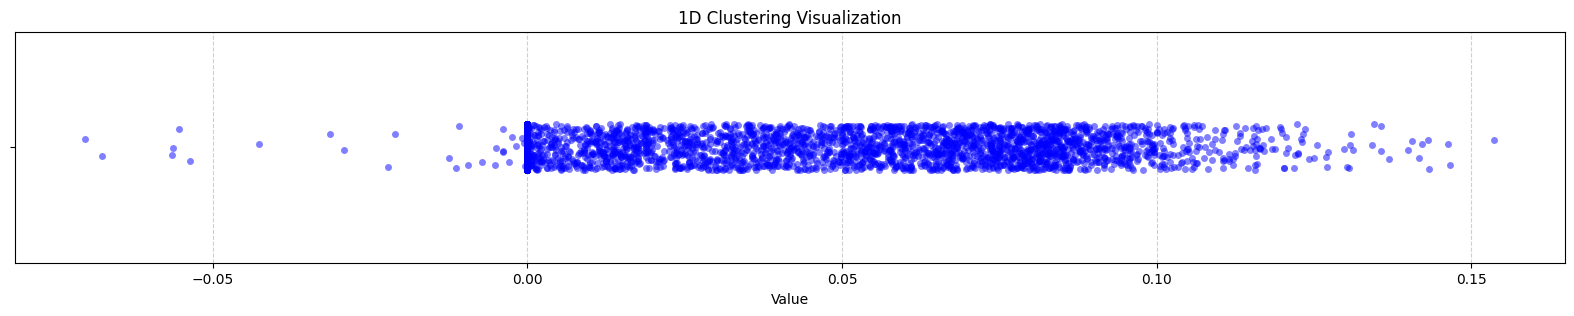

pvals


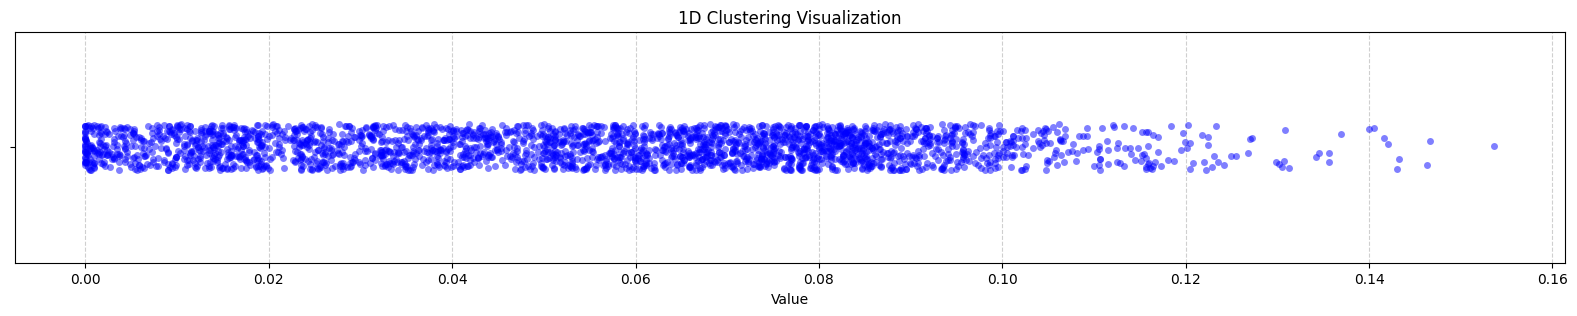

nvals


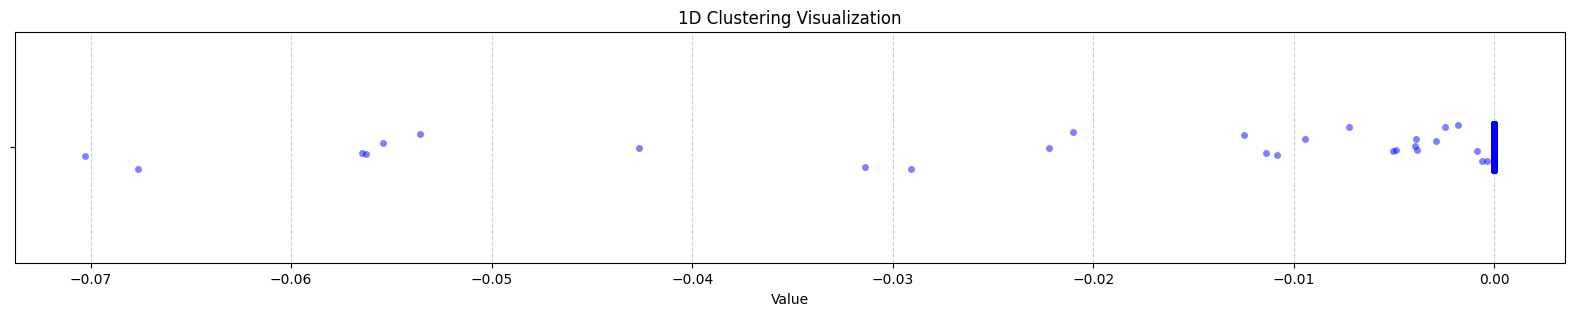

(np.float64(0.05252243877829671), np.float64(-0.028957475901204788))

In [6]:
# oopsie doopsie, there is no distribution lol
# is this even maneagable?
# im at the same problem where i need to cluster manually
vals = list(itertools.chain.from_iterable(poi_by_vals.values()))

print("all")
scatter_plot_1d(list(itertools.chain.from_iterable(poi_by_vals.values())))
pvals = [v for v in vals if v > 0]
nvals = [v for v in vals if v < 0]
print("pvals")
scatter_plot_1d(pvals)
print("nvals")
scatter_plot_1d(nvals)
pos_thresh = otsu_threshold(pvals)
neg_thresh = otsu_threshold(nvals)
pos_thresh, neg_thresh

In [7]:
# get with lower thresholds
from neural_data.utils import (
    get_all_saliency_map_ids_and_patches,
    get_saliency_map_ids_and_patches,
)


sm_ids, patches = get_saliency_map_ids_and_patches(
    (R, C), KERNEL_COORDINATE, INPUT_LAYER_NAME, pos_thresh, neg_thresh
)
# sm_ids, patches = get_all_saliency_map_ids_and_patches(
#     KERNEL_COORDINATE, INPUT_LAYER_NAME, pos_thresh, neg_thresh
# )
pw = [p * kernel for p in patches]
lin_pw = np.array([p.reshape(-1) for p in pw])
lin_patches = np.array([p.reshape(-1) for p in patches])

100%|██████████| 5502/5502 [00:02<00:00, 1970.05it/s]


# metrics and functions

In [8]:
from typing import Literal


def _single_dict_learn(
    X, n_components, alg: Literal["minibatch", "basic"], seed=None, **kwargs
):
    clz = DictionaryLearning if alg == "basic" else MiniBatchDictionaryLearning
    dl = clz(n_components=n_components, random_state=seed, **kwargs)
    dl.fit(X)
    codes = dl.transform(X)
    error = np.mean((X - codes @ dl.components_) ** 2)
    new_comps = finetune_dictionary(X, dl.components_, codes)
    dl.components_ = new_comps
    return dl, codes, error


def finetune_dictionary(X, atoms, sparse_codes, lr=1e-4, n_iter=500, lam=1e-3):
    """
    X: (n_samples, n_features)
    atoms: (n_atoms, n_features)
    sparse_codes: (n_samples, n_atoms)
    """
    A = atoms.copy().astype(float)
    Z = sparse_codes.T  # (n_atoms, n_samples)

    for i in range(n_iter):
        residual = X - Z.T @ A  # (n_samples, n_features)
        # print(residual.sum())
        grad = -2 * Z @ residual  # (n_atoms, n_features)
        grad += 2 * lam * A  # L2 regularization
        A -= lr * grad

    return A


def do_dict_learn(
    inputs,
    n_components,
    alg: Literal["minibatch", "basic"] = "basic",
    n_init=5,
    **kwargs,
):
    # X = Normalizer("max").fit_transform(inputs)
    X = inputs.copy()
    kwargs = {
        "alpha": 1,
        "max_iter": 5000,
        "fit_algorithm": "cd",
        "positive_code": True,
        **kwargs,
    }
    if n_init == 1:
        dl, codes, error = _single_dict_learn(X, n_components, alg, None, **kwargs)
        return (dl, codes, X), [dl]

    best_dl, best_codes, best_error = None, None, np.inf
    all_dls = []
    for seed in range(n_init):
        dl, codes, error = _single_dict_learn(X, n_components, alg, seed, **kwargs)
        all_dls.append(dl)
        if error < best_error:
            best_dl, best_codes, best_error = dl, codes, error
    return (best_dl, best_codes, X), all_dls


In [9]:
def get_sparse_codes_ratio_with_more_than_1_active_node(
    sparse_codes, alpha_for_code_below=0.05
):
    idxes = []
    for i in range(len(sparse_codes)):
        non_zero_codes = sparse_codes[i][sparse_codes[i] != 0]
        if len(non_zero_codes) == 0:
            continue
        non_zero_codes = np.abs(non_zero_codes)
        max_val_idx = np.argmax(non_zero_codes)
        thresh = non_zero_codes[max_val_idx] * alpha_for_code_below

        gt_thresh = []
        for j in range(len(non_zero_codes)):
            if j == max_val_idx:
                continue
            if non_zero_codes[j] > thresh:
                gt_thresh.append(non_zero_codes[j])
        if len(gt_thresh) > 0:
            idxes.append(i)

    return len(idxes) / sparse_codes.shape[0]


def plot_error_metrics(l2_dicts):
    df = pd.DataFrame.from_dict(l2_dicts, orient="index")
    metrics = ["max", "mean", "50", "75", "90", "95"]
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))

    for ax, metric in zip(axes.flatten(), metrics):
        ax.plot(df.index, df[metric])
        ax.set_title(metric)
    plt.show()


def get_loss(dl, sparse_codes, X):
    reconstructed = sparse_codes @ dl.components_
    diff = X - reconstructed
    err_sq = np.linalg.norm(diff, axis=1)
    return err_sq


def get_metrics(dl, sparse_codes, X):
    err_sq = get_loss(dl, sparse_codes, X)
    _p = np.percentile
    metrics = {
        "l2": {
            "max": np.max(err_sq),
            "mean": np.mean(err_sq),
            "50": _p(err_sq, 50),
            "75": _p(err_sq, 75),
            "90": _p(err_sq, 90),
            "95": _p(err_sq, 95),
        },
        "err": err_sq,
    }
    return metrics


def show_dl_comps(comps):
    c = list(itertools.chain.from_iterable([tsl(c.reshape(8, 3, 3)) for c in comps]))
    S(c, (20, 15), 8, mode=MODE)
    plt.show()


def get_sparsity_in_rows(sparse_codes):
    # < 0.2 is good, < 0.1 is quite nice
    each_row_sparsity = (sparse_codes != 0).sum(axis=1) / sparse_codes.shape[1]
    _p = np.percentile
    return {
        "max": np.max(each_row_sparsity),
        "mean": np.mean(each_row_sparsity),
        "50": _p(each_row_sparsity, 50),
        "75": _p(each_row_sparsity, 75),
        "90": _p(each_row_sparsity, 90),
        "95": _p(each_row_sparsity, 95),
    }

In [10]:
def make_sparse(patch, num_std=1):
    mean, std = np.mean(patch), np.std(patch)
    thresh = mean + num_std * std

    sparse = patch.copy()
    sparse[np.abs(sparse) < thresh] = 0
    return sparse

# Our encoder try

In [11]:
from torch import nn
from torch import optim


class GroupingAutoencoderFixedSigma(nn.Module):
    def __init__(self, input_dim, n_components):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, n_components, bias=True),
        )
        self.decoder = nn.Linear(n_components, input_dim, bias=False)

    def forward(self, x):
        codes = self.encoder(x)
        recon = self.decoder(codes)
        return recon, codes

    def loss_fn(self, x, recons, codes, alpha, sigma_x, sigma_s, sigma_0):
        recons_loss = self.recon_loss(x, recons, sigma_x)

        codes_loss = self.codes_loss(codes, sigma_s)

        weights_loss = self.weights_loss(alpha, sigma_0)

        return recons_loss, codes_loss, weights_loss

    def codes_loss(self, codes, sigma_s):
        return self.gauss_loss(codes, 0) / (sigma_s * sigma_s)

    def recon_loss(self, x, recons, sigma_x):
        return self.gauss_loss(x, recons) / (sigma_x * sigma_x)

    def cauchy_loss(self, x, cauchy_gamma):
        return torch.log(1 + (x * x) / (cauchy_gamma * cauchy_gamma)).sum()

    def cauchy_codes_loss(self, codes, cauchy_gamma):
        return (
            torch.log(1 + (codes * codes) / (cauchy_gamma * cauchy_gamma)).sum(1).mean()
        )

    def gauss_loss(self, x, mean):
        loss = (x - mean) ** 2
        # sum the loss inside one example, send back mean across examples for the batch
        return torch.sum(loss, 1).mean()

    def l1_loss(self, x, mean):
        loss = (x - mean).abs()
        return torch.sum(loss, 1).mean()

    def weights_loss(self, alpha, sigma_0):
        W = self.decoder.weight
        W_sq = W**2  # (C, K)
        cumsum = torch.cumsum(W_sq, dim=1)  # (C, K), cumsum[c,k] = sum W[c,0..k]^2
        phi = alpha * torch.roll(cumsum, 1, dims=1) + 1  # (C, K)
        phi[:, 0] = 1  # k=0: phi_weight(W, c, -1, alpha) = alpha*0 + 1
        comp1 = (W_sq * phi) / (sigma_0 * sigma_0)
        comp2 = -torch.log(phi)
        return comp1, comp2

    def masked_recon_loss(self, x, recons, sigma_x):
        mask = (x != 0).float()
        loss = ((x - recons) ** 2) * mask
        return torch.sum(loss, 1).mean() / (sigma_x**2)

    def weights_loss_cycled(self, alpha, sigma_0, chunk_size=64):
        W = self.decoder.weight          # (C, K)
        C, K = W.shape

        idx = (torch.arange(K, device=W.device).unsqueeze(0) +
            torch.arange(K, device=W.device).unsqueeze(1)) % K   # (K, K)

        shift_losses = []

        for start in range(0, K, chunk_size):
            idx_chunk = idx[start:start + chunk_size]   # (chunk, K)

            W_chunk = W[:, idx_chunk]                   # (C, chunk, K)
            W_chunk = W_chunk.permute(1, 0, 2)          # (chunk, C, K)

            W_sq = W_chunk ** 2

            cumsum = torch.cumsum(W_sq, dim=2)
            phi = alpha * torch.roll(cumsum, 1, dims=2) + 1
            phi[:, :, 0] = 1

            comp1 = (W_sq * phi) / (sigma_0 * sigma_0)
            comp2 = -torch.log(phi)

            shift_losses.append((comp1 + comp2).sum(dim=(1, 2)))  # (chunk,)

        return torch.cat(shift_losses).mean()

def get_alpha(epoch, total_epochs, alpha_start=0.0, alpha_end=1.0):
    # do the last 25% with max_alpha
    epoch_max = int(total_epochs * 0.30)
    return alpha_start + (alpha_end - alpha_start) * (epoch / epoch_max)


def train_grouping_autoencoder_fixed_sigma(
    X,
    n_components,
    max_alpha=5000,
    sigma_x=0.1,
    sigma_s=1,
    sigma_0=1,
    lr=1e-3,
    epochs=2000,
    batch_size=256,
):
    """
    X: numpy array (n_samples, input_dim)
    n_components: number of dictionary atoms
    alpha: lorentzian sigma shrinker parameter
    sigma_x: std of noise in the data after modelling it as a WS
    sigma_0: std of W, useful to keepn very near 0
    sigma_s: cauchy gamma for cauchy penalty on the encoder (useful for sparse weights)
       the name is sigma_s, cuz it was used as a gaussian prior (L2) on encoder weights, for data which is not sparse
    """
    X_t = torch.tensor(X, dtype=torch.float32)
    n_samples, input_dim = X_t.shape

    model = GroupingAutoencoderFixedSigma(input_dim, n_components)
    # torch.nn.init.normal_(model.decoder.weight, 0, 1)

    # svd, might add back again later
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    model.decoder.weight.data = torch.tensor(Vt[:n_components].T, dtype=torch.float32)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        # shuffle
        idx = torch.randperm(n_samples)
        permuted_X_t = X_t[idx]

        for i in range(0, n_samples, batch_size):
            batch = permuted_X_t[i : i + batch_size]

            # first do on recons, let everything flow, make LR for weight 0
            recon, codes = model(batch)
            recon_loss = model.recon_loss(batch, recon, sigma_x)
            # alpha = get_alpha(epoch, epochs, 100, max_alpha)
            alpha = max_alpha
            # weights_comp1, weights_log_comp = model.weights_loss(alpha, sigma_0)
            # weight_loss = (weights_comp1 + weights_log_comp).sum()
            weight_loss = model.weights_loss_cycled(alpha, sigma_0)

            code_loss = model.gauss_loss(model.encoder[0].weight, 0) / (
                sigma_s * sigma_s
            )

            loss = recon_loss + weight_loss + code_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if epoch % 200 == 0:
            msg = f"epoch {epoch:4d} | recon_loss {recon_loss:.4f}"
            if weight_loss is not None:
                # msg += f" weight_comp1 {weights_comp1.sum():.4f} weights_log {weights_log_comp.sum():.4f} codes_loss {code_loss:.4f}"
                msg += f" weight_loss {weight_loss.sum():.4f} codes_loss {code_loss:.4f}"
            # msg += f" reg_weight: {reg_weight}"
            print(msg)

    # final codes and reconstruction
    with torch.no_grad():
        recon, codes = model(X_t)

    return (
        model,
        codes.numpy(),
        model.decoder.weight.T.detach().numpy(),  # (n_components, input_dim)
        recon.numpy(),
    )


def train_baseline(X, n_components, lr=1e-3, epochs=2000, batch_size=256, sigma_x=1):
    # simple linear model without any non linearities
    # for loss checking
    X_t = torch.tensor(X, dtype=torch.float32)
    n_samples, input_dim = X_t.shape

    model = GroupingAutoencoderFixedSigma(input_dim, n_components)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        idx = torch.randperm(n_samples)
        permuted_X_t = X_t[idx]
        for i in range(0, n_samples, batch_size):
            batch = permuted_X_t[i : i + batch_size]
            recon, codes = model(batch)
            recon_loss = model.recon_loss(batch, recon, sigma_x)
            loss = recon_loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        if epoch % 200 == 0:
            print(f"finetune epoch {epoch:4d} | recon_loss {recon_loss:.4f}")

    with torch.no_grad():
        recon, codes = model(X_t)

    return (
        model,
        codes.numpy(),
        model.decoder.weight.T.detach().numpy(),  # (n_components, input_dim)
        recon.numpy(),
    )


def show_gram(W):
    if not isinstance(W, torch.Tensor):
        W = torch.tensor(W)
    W_norm = W / (W.norm(dim=0, keepdim=True) + 1e-8)
    gram = W_norm.T @ W_norm  # (n_components, n_components)
    plt.imshow(gram, cmap="gray")
    plt.show()
    return gram

In [12]:
# sparse_pw = lin_pw
model, codes, components, recon = train_baseline(lin_pw, 11, 1e-3, 5000)
# baseline is not bad at all
show_72_list([recon[10], lin_pw[10]], mode=MODE)

finetune epoch    0 | recon_loss 3.8093
finetune epoch  200 | recon_loss 0.1083
finetune epoch  400 | recon_loss 0.0864
finetune epoch  600 | recon_loss 0.0833
finetune epoch  800 | recon_loss 0.0860
finetune epoch 1000 | recon_loss 0.0728
finetune epoch 1200 | recon_loss 0.0983
finetune epoch 1400 | recon_loss 0.0900
finetune epoch 1600 | recon_loss 0.0876
finetune epoch 1800 | recon_loss 0.0897
finetune epoch 2000 | recon_loss 0.0776
finetune epoch 2200 | recon_loss 0.0809
finetune epoch 2400 | recon_loss 0.0842
finetune epoch 2600 | recon_loss 0.0961
finetune epoch 2800 | recon_loss 0.0791
finetune epoch 3000 | recon_loss 0.0805
finetune epoch 3200 | recon_loss 0.0834
finetune epoch 3400 | recon_loss 0.0800
finetune epoch 3600 | recon_loss 0.0941
finetune epoch 3800 | recon_loss 0.1048
finetune epoch 4000 | recon_loss 0.0910
finetune epoch 4200 | recon_loss 0.0826
finetune epoch 4400 | recon_loss 0.0795
finetune epoch 4600 | recon_loss 0.0814
finetune epoch 4800 | recon_loss 0.0754


overall stats 8.317045162804906e-05 0.03430238649824573


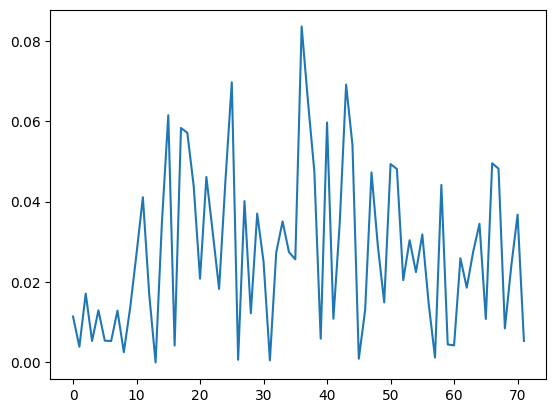

In [13]:
# std seems similar for dims.
# technically i can use different std for everyone
# but its ok
noise = lin_pw - recon
# mean is very close to zero
print("overall stats", noise.mean(), noise.std())
plt.plot(noise.std(0))
plt.show()

In [14]:
# from noise.mean() and noise.std()
noise_mean, noise_std = 0.0001623938428938167, 0.03430350051154822

In [15]:
print(np.std(lin_pw) / noise_std)
scaled_baseline_loss = 0.087 / (noise_std * noise_std)
scaled_baseline_loss

6.227480917318995


73.93368836197118

In [16]:
sigma_w = noise_std * 5
sigma_s = sigma_w
print(sigma_s)

model, codes, components, recon = train_grouping_autoencoder_fixed_sigma(
    lin_pw,
    10,
    # it bounces wildly xD
    max_alpha=5000 * (1 / (sigma_w*sigma_w)),
    sigma_x=noise_std,
    sigma_s=sigma_s,
    sigma_0=sigma_w,
    lr=1e-3,
    epochs=8000,
)

0.17151750255774112
epoch    0 | recon_loss 2928.3352 weight_loss 11279283.0000 codes_loss 10.9491
epoch  200 | recon_loss 640.2704 weight_loss 23075.1523 codes_loss 89.8277
epoch  400 | recon_loss 694.3437 weight_loss -1151.2078 codes_loss 103.9649
epoch  600 | recon_loss 727.0934 weight_loss -2556.4810 codes_loss 100.1694
epoch  800 | recon_loss 723.8011 weight_loss -2668.9607 codes_loss 104.8958
epoch 1000 | recon_loss 628.8663 weight_loss -2667.8013 codes_loss 113.6130
epoch 1200 | recon_loss 521.6321 weight_loss -2669.5190 codes_loss 122.2260
epoch 1400 | recon_loss 499.0698 weight_loss -2684.8020 codes_loss 110.9709
epoch 1600 | recon_loss 444.4152 weight_loss -2685.6853 codes_loss 104.1428
epoch 1800 | recon_loss 318.3908 weight_loss -2715.1516 codes_loss 107.3729
epoch 2000 | recon_loss 287.5230 weight_loss -2727.8687 codes_loss 93.2352
epoch 2200 | recon_loss 279.8451 weight_loss -2743.3379 codes_loss 85.1252
epoch 2400 | recon_loss 301.7987 weight_loss -2745.0874 codes_loss 7

In [17]:
lin_pw.shape

(1449, 72)

In [24]:
from sklearn import decomposition
# Global centering (focus on one feature, centering all samples)
lin_pw_centered = lin_pw - lin_pw.mean(axis=0)

# Local centering (focus on one sample, centering all features)
lin_pw_centered -= lin_pw_centered.mean(axis=1).reshape(lin_pw.shape[0], -1)
ica_estimator = decomposition.FastICA(
    n_components=10, max_iter=20000, whiten="arbitrary-variance", tol=15e-5
)
ica_estimator.fit(lin_pw_centered)

ica_codes = ica_estimator.transform(lin_pw_centered)
ica_recon = ica_estimator.inverse_transform(codes)
ica_comps = ica_estimator.components_



/Users/hariomnarang/Desktop/personal/hiccup-ide/backend/.venv/lib/python3.13/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


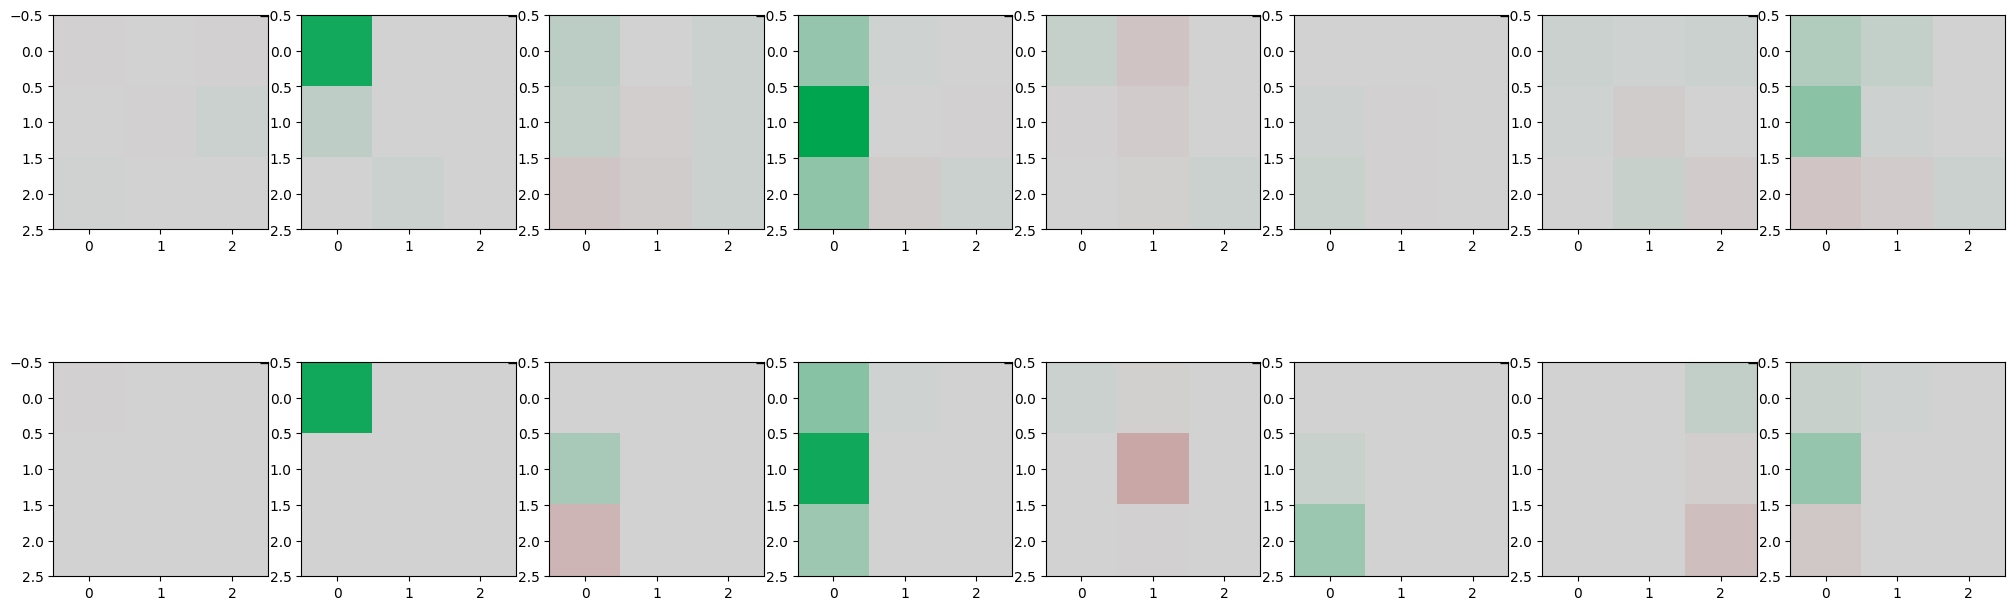

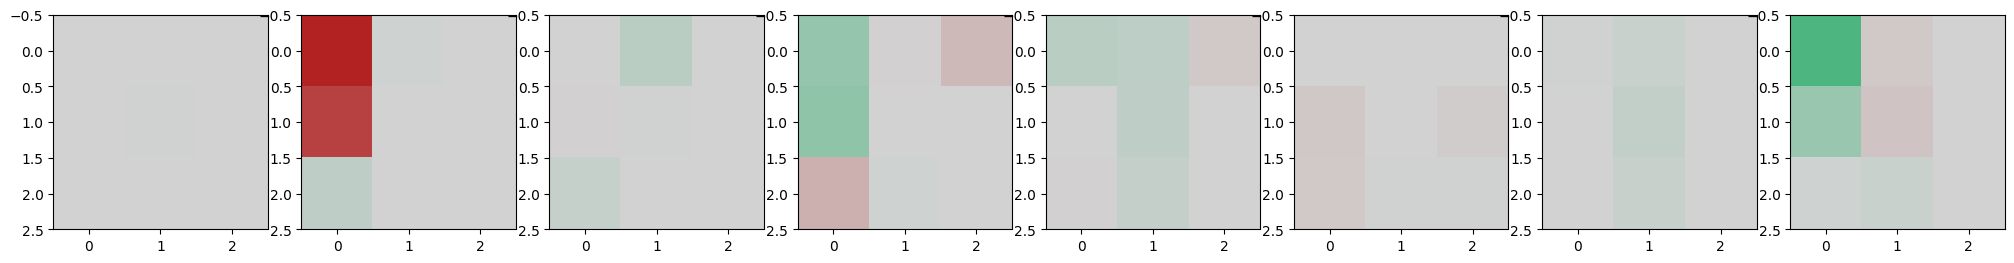

In [37]:
# loss is 3 times the scaled baseline loss, although it was still coming down
# its not the worst, there is a lot more noise though in the reconstruction
i = 12
show_72_list([recon[i], lin_pw[i]], viztype="global", mode=MODE)
show_72(ica_recon[i], mode=MODE)

In [40]:
components.shape

(10, 72)

In [39]:
ica_comps.shape

(10, 72)

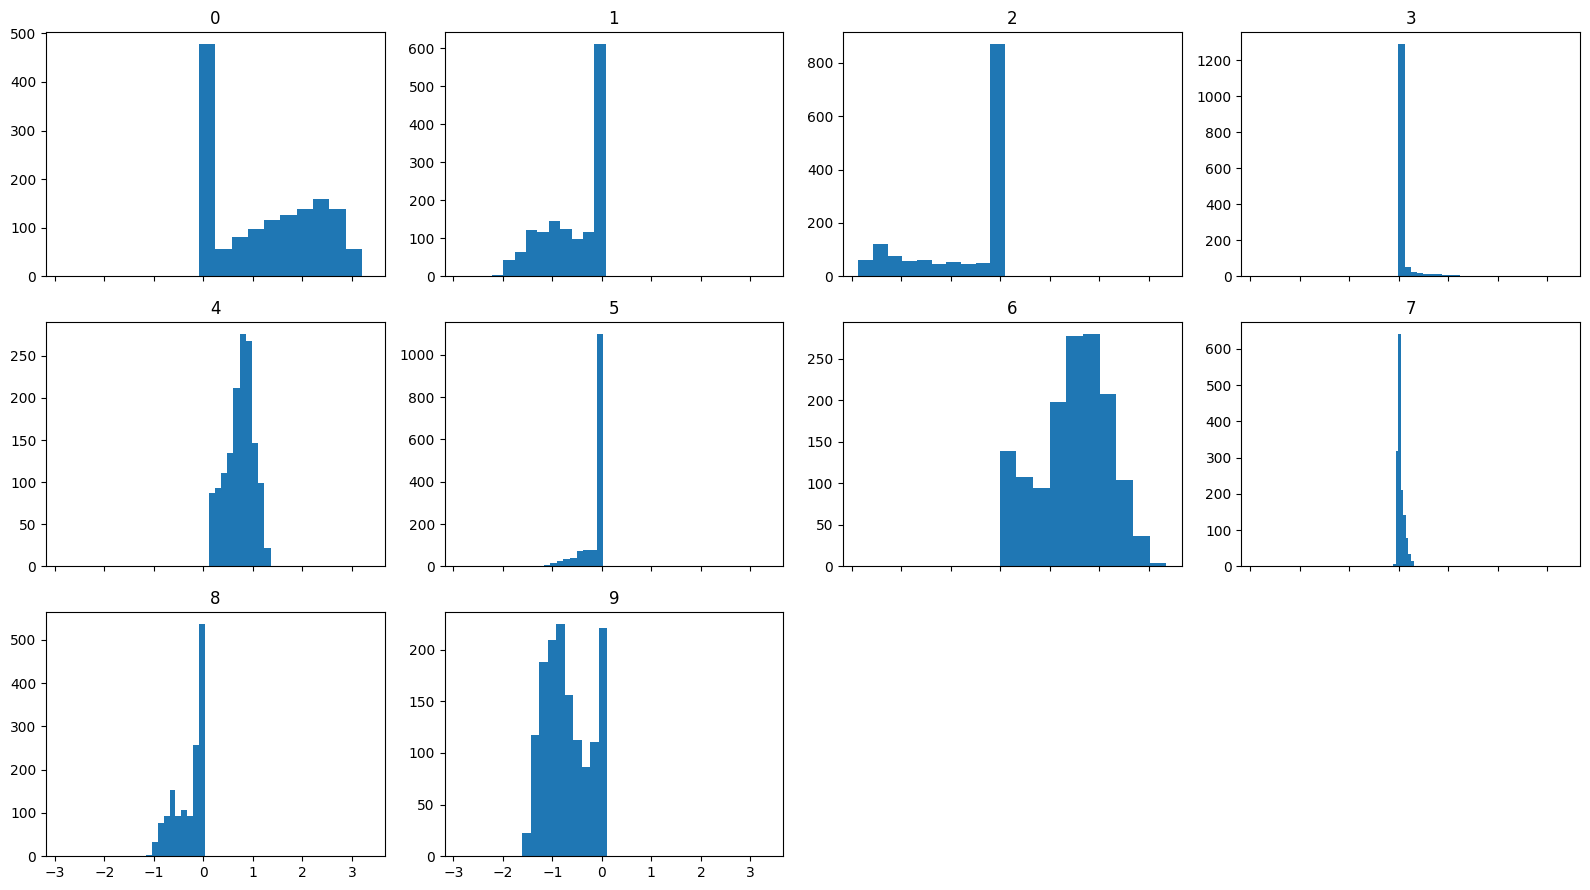

In [541]:
import math
cols = 4
rows = math.ceil(codes.shape[1] / cols)
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows), sharex=True)

for i, ax in enumerate(axes.flat):
    if i < codes.shape[1]:
        ax.hist(codes[:, i])
        ax.set_title(f"{i}")
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

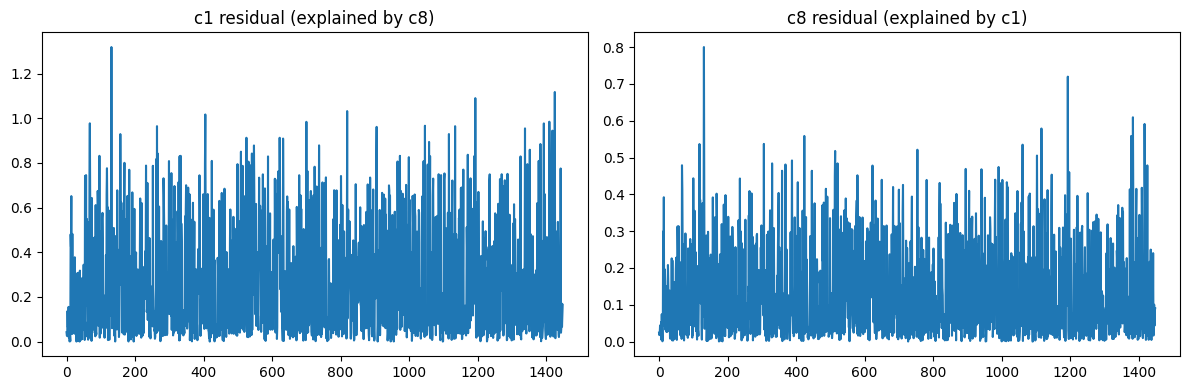

In [561]:
c1, c8 = codes[:, 1], codes[:, 8]

scale_18 = (c1 @ c8) / (c8 @ c8 + 1e-8)
scale_81 = (c8 @ c1) / (c1 @ c1 + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False)

axes[0].plot(np.abs(c1 - scale_18 * c8))
axes[0].set_title('c1 residual (explained by c8)')

axes[1].plot(np.abs(c8 - scale_81 * c1))
axes[1].set_title('c8 residual (explained by c1)')

plt.tight_layout()
plt.show()

array([<Axes: >, <Axes: >], dtype=object)

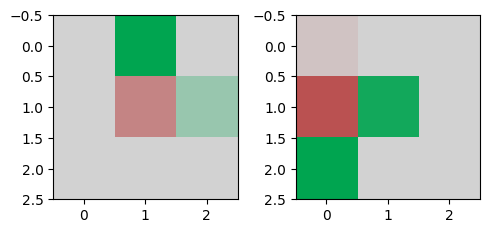

In [ ]:
# i cant have crazy decomposition lol
# this is good enough though, these are extremely low signals
S([c[0].reshape(8,3,3)[3], c[2].reshape(8,3,3)[2]], mode=MODE, viztype="local")

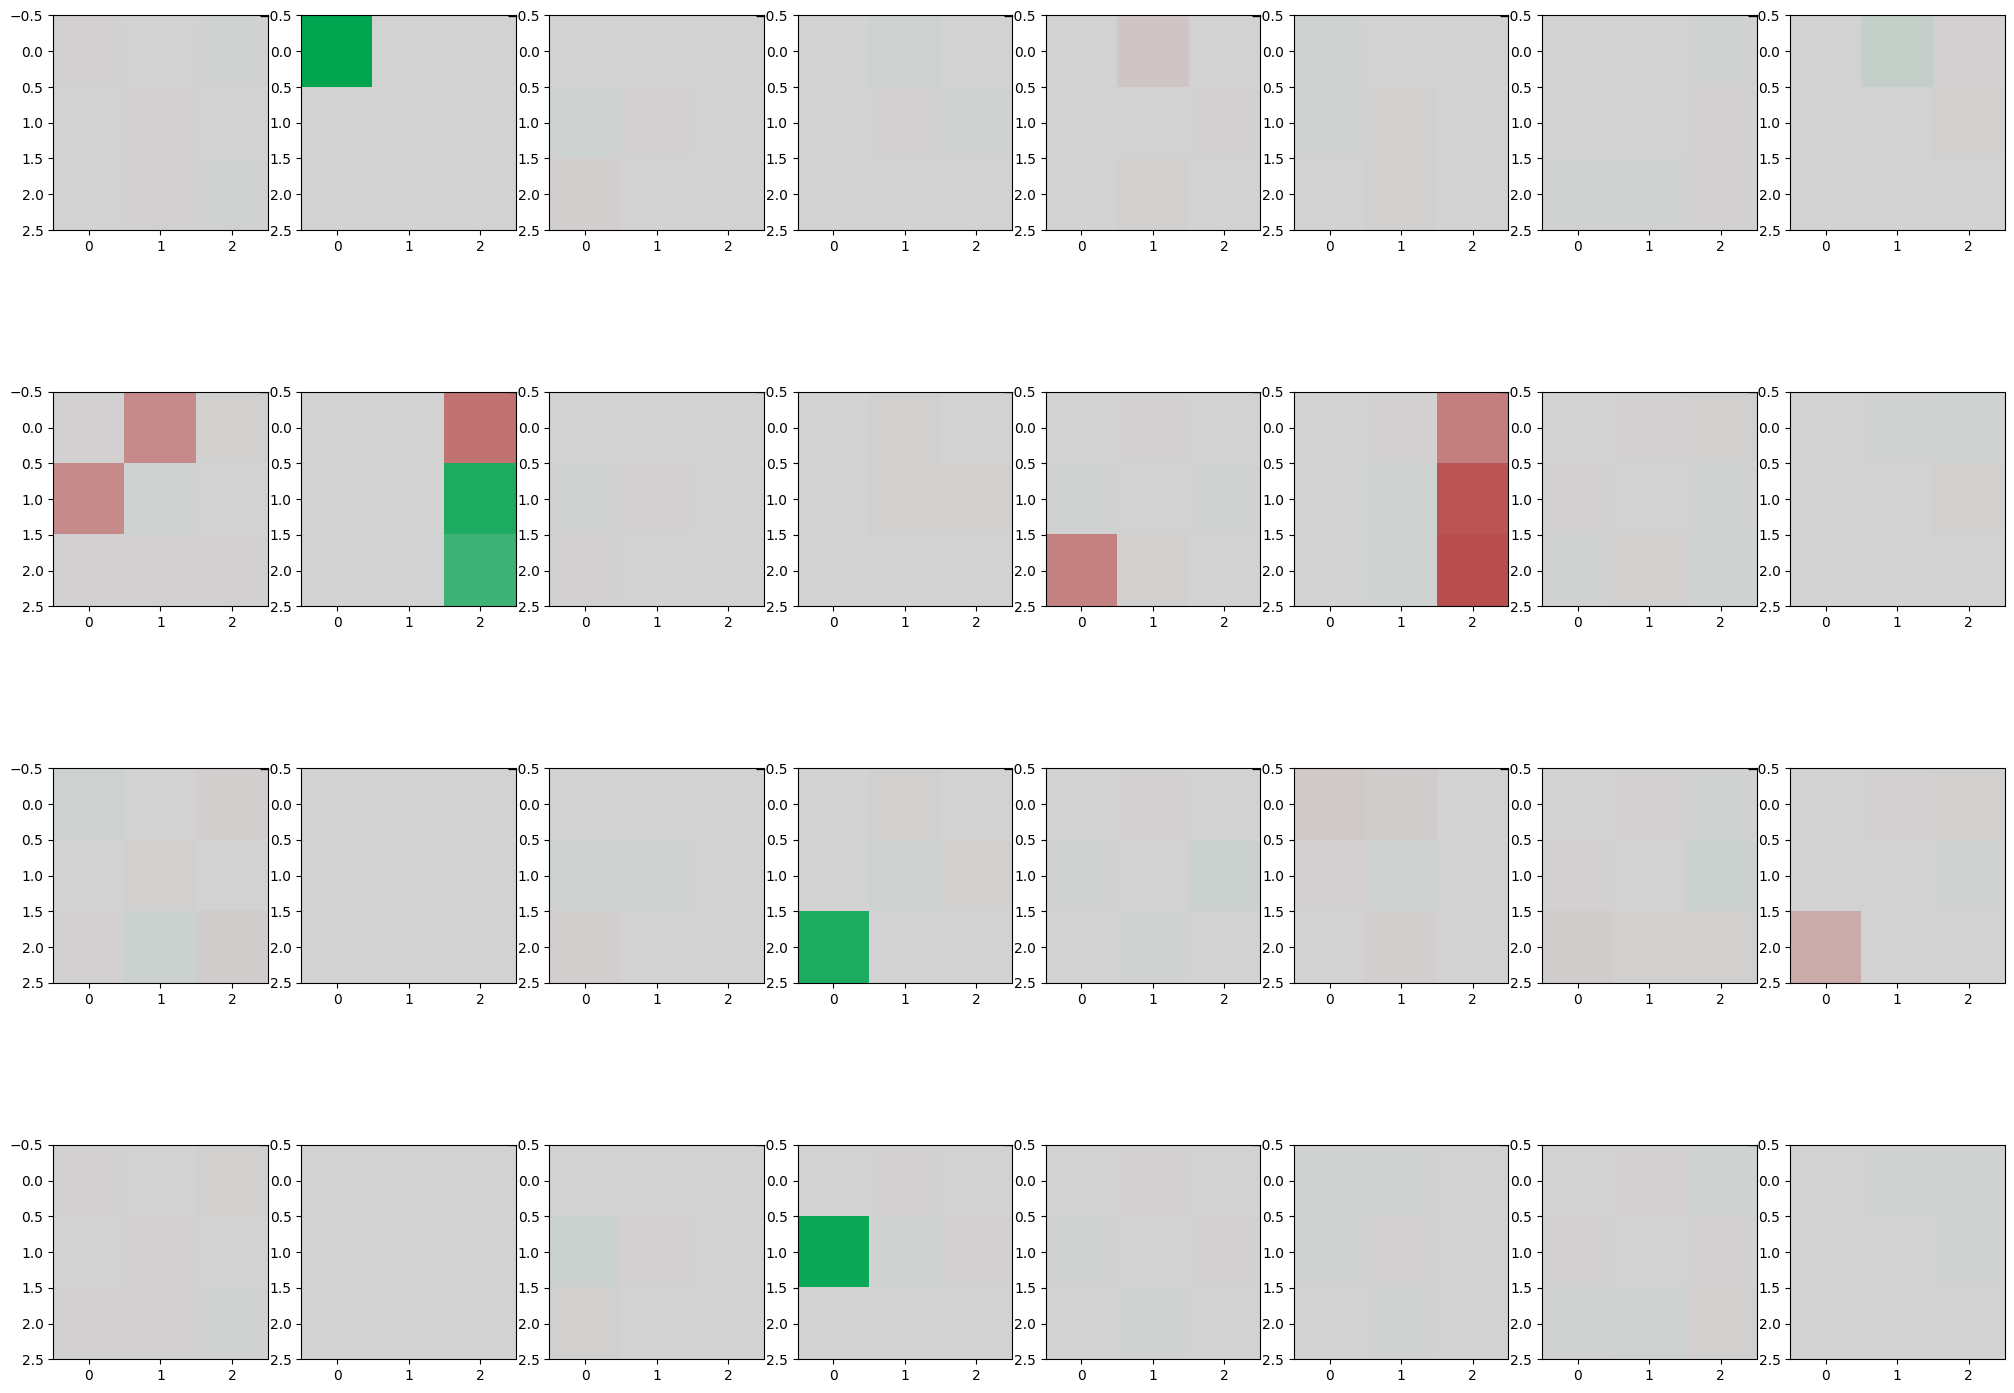

In [562]:
c = components
show_72_list([c[0],c[3],c[4],c[6]], mode=MODE)

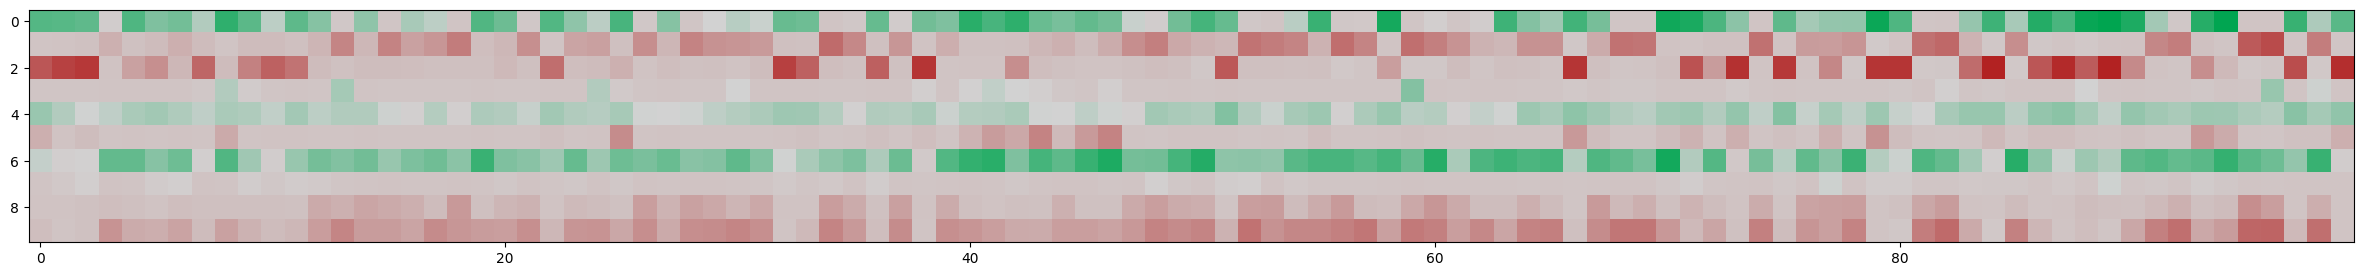

In [543]:
# we want to see
# which dimensions are high together
# in codes
# the gram matrix might be useful?
# no, lets first just see the simple image
from pt_to_api.utils import rd_wht_gn

_, ax = plt.subplots(1,1,figsize=(30,5))
ax.imshow(codes[:100, :].T, cmap=rd_wht_gn )
plt.show()

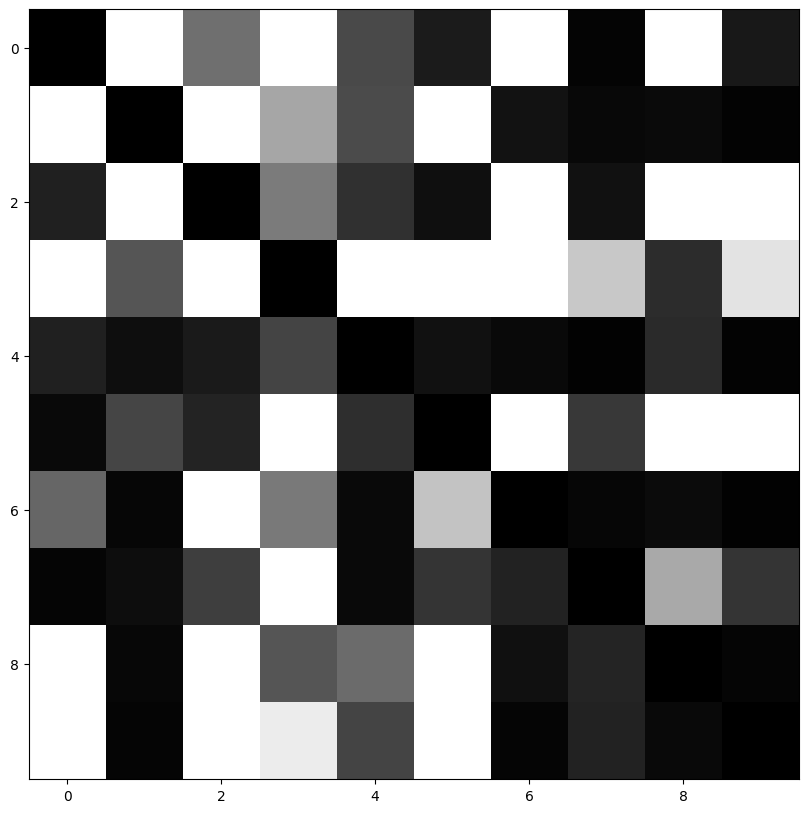

In [547]:
# (N, K) -> for each pair (i, j): fit scale = mean(ci / cj), measure residual
# vectorized: scale[i,j] = mean(codes[:,i] / codes[:,j])
# residual[i,j] = mean(|ci - cj * scale[i,j]|)

C = codes[:200]  # (N, K)

# scale[i,j] = mean over N of (C[:,i] / C[:,j])
scale = (C[:, :, None] / (C[:, None, :] + 1e-8)).mean(axis=0)  # (K, K)

# residual[i,j] = mean over N of |C[:,i] - C[:,j] * scale[i,j]|
# residual = np.abs(C[:, :, None] - C[:, None, :] * scale[None, :, :]).mean(axis=0)  # (K, K)
residual = (np.abs(C[:, :, None] - C[:, None, :] * scale[None, :, :]) / 
            (np.abs(C[:, :, None]) + 1e-8)).mean(axis=0)

_, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(residual, cmap="gray", vmin=0, vmax=100)
plt.show()

In [553]:
active = codes > 0  # (N, K) boolean, adjust threshold if needed
co_activation = (active[:, :, None] & active[:, None, :]).mean(axis=0)  # (K, K)

np.fill_diagonal(co_activation, 0)

# pretty print pairs
threshold = 0.3
pairs = []
for i in range(len(co_activation)):
    for j in range(i+1, len(co_activation)):  # upper triangle only, since symmetric
        if co_activation[i, j] > threshold:
            pairs.append((co_activation[i, j], i, j))

pairs.sort(reverse=True)
for r, i, j in pairs:
    print(f"  {i} — {j}  {r:.2f}")

  4 — 6  1.00
  3 — 4  0.93
  3 — 6  0.93
  0 — 4  0.87
  0 — 6  0.86
  0 — 3  0.80
  4 — 7  0.61
  6 — 7  0.61
  0 — 7  0.59
  3 — 7  0.55


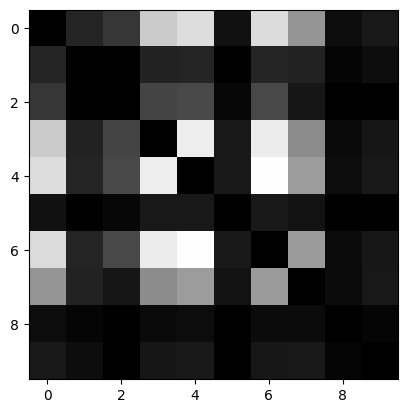

In [555]:
plt.imshow(co_activation, cmap="gray", vmin=0, vmax=1)

In [558]:
co_activation

array([[0.00000000e+00, 1.41476881e-01, 2.13250518e-01, 7.95031056e-01,
        8.66804693e-01, 6.76328502e-02, 8.62663906e-01, 5.85231194e-01,
        4.69289165e-02, 9.38578330e-02],
       [1.41476881e-01, 0.00000000e+00, 0.00000000e+00, 1.33195307e-01,
        1.41476881e-01, 0.00000000e+00, 1.41476881e-01, 1.33885438e-01,
        2.07039337e-02, 5.10697032e-02],
       [2.13250518e-01, 0.00000000e+00, 0.00000000e+00, 2.68461008e-01,
        2.83643892e-01, 2.82953761e-02, 2.83643892e-01, 8.90269151e-02,
        0.00000000e+00, 0.00000000e+00],
       [7.95031056e-01, 1.33195307e-01, 2.68461008e-01, 0.00000000e+00,
        9.28226363e-01, 9.38578330e-02, 9.25465839e-01, 5.50034507e-01,
        3.93374741e-02, 8.69565217e-02],
       [8.66804693e-01, 1.41476881e-01, 2.83643892e-01, 9.28226363e-01,
        0.00000000e+00, 9.52380952e-02, 9.95859213e-01, 6.12146308e-01,
        4.69289165e-02, 9.38578330e-02],
       [6.76328502e-02, 0.00000000e+00, 2.82953761e-02, 9.38578330e-02,
   

In [ ]:
# scale_ij = (ci · cj) / (cj · cj)  →  vectorized over all pairs
dot_ij = codes.T @ codes                          # (K, K)  ci · cj
norm_sq = np.einsum('ij,ij->j', codes, codes)     # (K,)    cj · cj

scale = dot_ij / (norm_sq[None, :] + 1e-8)        # (K, K)

# residual[i,j] = ||ci - scale_ij * cj||² / ||ci||²
# ci - scale_ij * cj  →  for all pairs: codes @ I - scale * codes
# numerator[i,j] = ||ci||² - 2*scale_ij*(ci·cj) + scale_ij²*||cj||²
numerator = (norm_sq[:, None]
             - 2 * scale * dot_ij
             + scale**2 * norm_sq[None, :])        # (K, K)

residual = numerator / (norm_sq[:, None] + 1e-8)   # (K, K)

np.fill_diagonal(residual, 0)


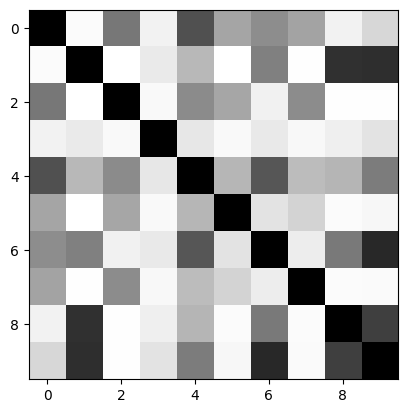

In [549]:
plt.imshow(residual, cmap="gray", vmin=0, vmax=1)

In [552]:
residual[6][9], residual[1][8]

(np.float32(0.15995122), np.float32(0.19503948))

In [546]:
threshold = 10
pairs = []
for i in range(len(residual)):
    for j in range(len(residual)):
        if i != j and residual[i, j] < threshold:
            pairs.append((residual[i, j], i, j))

pairs.sort()
for r, i, j in pairs:
    print(f"  {i} → {j}  {r:.2f}")

  4 → 7  0.93
  6 → 9  1.04
  1 → 9  1.36
  4 → 9  1.38
  0 → 7  1.72
  8 → 9  2.13
  9 → 6  2.18
  7 → 0  2.21
  9 → 1  2.32
  6 → 7  2.40
  6 → 1  2.64
  8 → 1  2.86
  1 → 7  3.51
  7 → 4  3.54
  9 → 8  3.58
  4 → 6  3.61
  5 → 0  3.66
  6 → 4  3.69
  1 → 8  4.27
  6 → 8  4.66
  7 → 1  5.14
  4 → 1  5.73
  2 → 5  5.93
  8 → 6  6.40
  4 → 5  6.73
  2 → 7  6.80
  1 → 6  7.14
  0 → 9  9.46


In [545]:
with np.printoptions(suppress=True, precision=4):
    print(residual)

[[   0.      459.175    43.5322  341.2405   29.155    10.5606  111.3967
     1.7168  937.8043    9.4567]
 [ 943.2518    0.     1038.8108   65.0766   29.5434  401.6987    7.1426
     3.5082    4.2747    1.3589]
 [  12.5378  275.8654    0.       48.3241   19.428     5.9252  341.2278
     6.8022 1072.6073  406.4164]
 [2066.0103   33.4515  656.0775    0.      152.9011  139.9868  197.944
    78.4312   17.5069   88.7523]
 [  12.7098    5.7274   10.1787   26.8538    0.        6.7346    3.61
     0.9331   16.5651    1.377 ]
 [   3.6616   27.3323   13.7728  596.2521   18.2981    0.      132.2915
    22.6001  383.2581  607.9211]
 [  39.9561    2.6408  217.2921   47.7893    3.6948   76.436     0.
     2.4004    4.6612    1.0357]
 [   2.2099    5.1429   24.2345  257.5646    3.5407   20.6364   13.5813
     0.       66.318    20.7706]
 [ 983.7789    2.8554 1655.7881   33.3863   42.177   657.9166    6.3964
    14.2756    0.        2.1331]
 [ 508.0944    2.3192 1364.4137   92.2525   26.9059  560.126  

In [538]:
with np.printoptions(suppress=True, precision=4):
    print(residual)

[[  0.       0.7108   1.9152   3.5411   0.4357]
 [ 11.2168   0.     118.9345   9.2086  13.0133]
 [ 10.7152  43.7886   0.      55.6114   8.172 ]
 [  6.1482  22.7972  12.642    0.       5.0085]
 [  0.4342   1.3748   2.0835   3.0094   0.    ]]


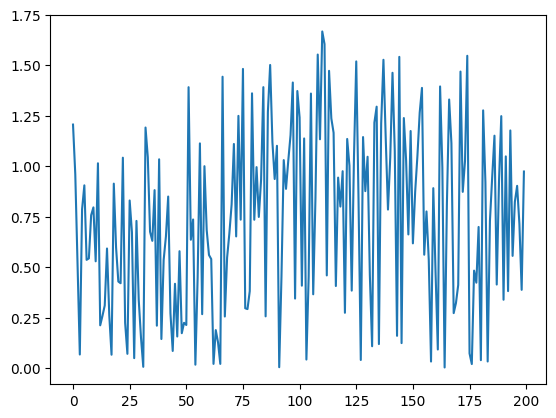

In [520]:
c0, c1 = codes[:200, 1], codes[:200, -1]
scale = (c0 / c1).mean()
plt.plot(np.abs(c0 - c1*scale))
plt.show()

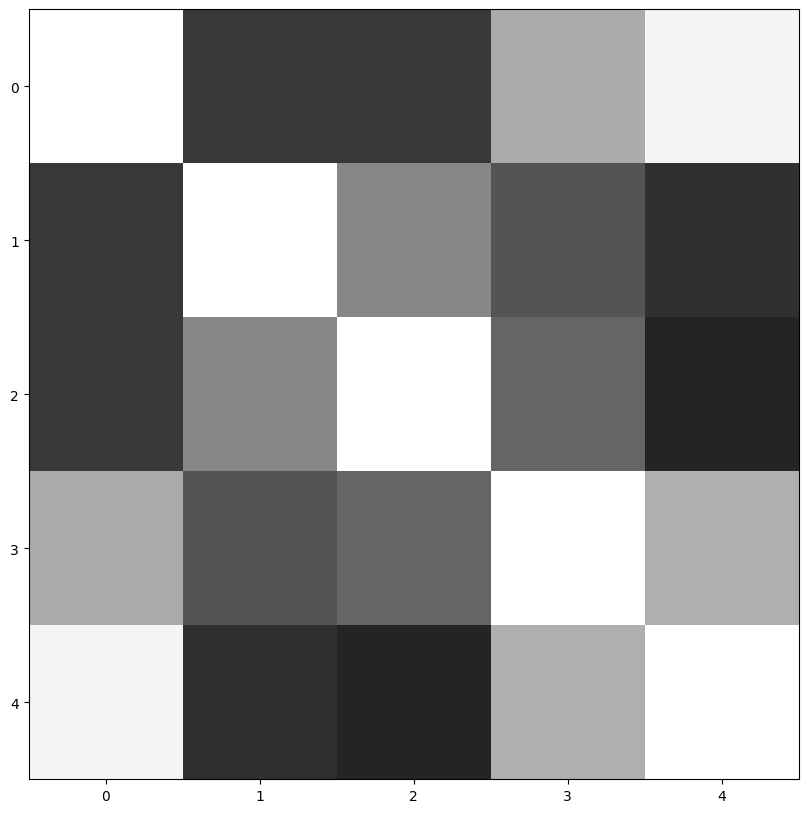

In [522]:
gram = codes.T @ codes  # (K, K)

# optionally normalize to correlation matrix
norms = np.sqrt(np.diag(gram))
corr = gram / np.outer(norms, norms)

_, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(corr, cmap="gray", vmin=-1, vmax=1)
plt.show()

In [505]:
codes[0]

array([ 1.5157003 , -0.06412569, -1.6525877 ,  0.02979247,  1.0229629 ],
      dtype=float32)

In [127]:
components[1][9], components[0][9]

(np.float32(-0.0020183213), np.float32(0.019996462))

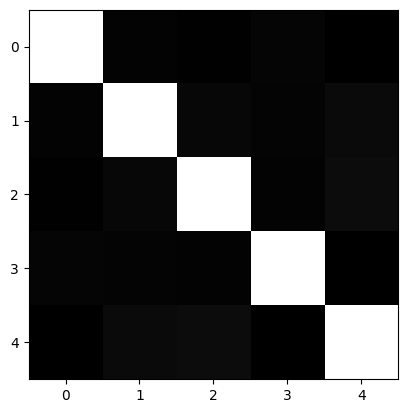

tensor([[ 1.0000e+00, -6.7676e-03, -1.3903e-02,  1.2671e-04, -2.0062e-02],
        [-6.7676e-03,  1.0000e+00,  9.2294e-03, -3.5679e-03,  2.3236e-02],
        [-1.3903e-02,  9.2294e-03,  1.0000e+00, -5.2704e-03,  2.9889e-02],
        [ 1.2671e-04, -3.5679e-03, -5.2704e-03,  1.0000e+00, -1.7905e-02],
        [-2.0062e-02,  2.3236e-02,  2.9889e-02, -1.7905e-02,  1.0000e+00]])

In [501]:
show_gram(components.T)

# alpha vs sigma

In [404]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


def phi(vals, alpha):
    return 1 + (alpha*(vals**2)).sum()

def sigma_cr_sq(sigma_0, vals, alpha):
    return (sigma_0*sigma_0) / phi(vals, alpha)

def plot_normal(sigma):
    x = np.linspace(-5*sigma, 5*sigma, 1000)
    y = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * (x / sigma)**2)
    plt.plot(x, y)
    plt.title(f'Normal distribution (σ={sigma})')
    plt.xlabel('x'); plt.ylabel('density')
    plt.show()


def plot_fancy(sigma_0, alpha, num_prior_weights_list):
    x = np.linspace(-5*sigma_0, 5*sigma_0, 1000)
    colors = plt.cm.viridis(np.linspace(0, 1, len(num_prior_weights_list)))
    
    for num_prior_weights, color in zip(num_prior_weights_list, colors):
        vals = sample_normal(sigma_0, num_prior_weights)
        print("sampled-values-by-sigma", vals / sigma_0)
        _sigma_sq = sigma_cr_sq(sigma_0, vals, alpha)
        print("sigma_ratios", _sigma_sq / (sigma_0 * sigma_0))
        y = (1 / (np.sqrt(2 * np.pi * _sigma_sq))) * np.exp(-0.5 * (x**2 / _sigma_sq))
        plt.plot(x, y, color=color, label=f'n={num_prior_weights}')
    
    plt.legend()
    plt.title(f'Normal distribution (σ={sigma_0})')
    plt.xlabel('x'); plt.ylabel('density')
    plt.show()

def sample_normal(sigma, n):
    return np.random.normal(0, sigma, n)

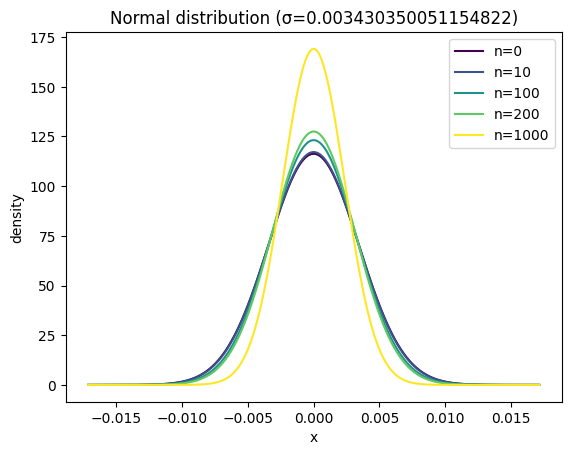

In [ ]:
# 0 case is the basic normal distributon, with less alpha, it stays quite normal
plot_fancy(sigma_w, 100, [0, 10, 100, 200, 1000])

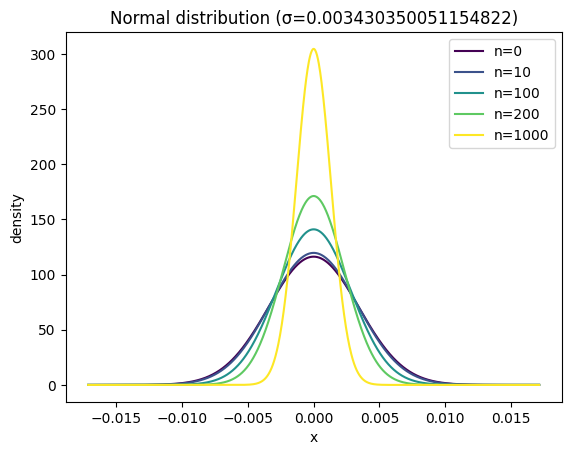

In [ ]:
# we see it getting thinner
plot_fancy(sigma_w, 500, [0, 10, 100, 200, 1000])

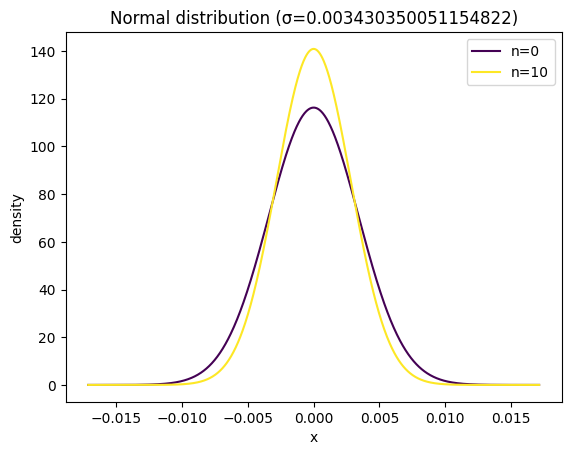

In [ ]:
# we see it getting thinner
# this is still not enough, quite intersting. mostly cuz sigma is too low
plot_fancy(sigma_w, 5000, [0, 10])

In [307]:
sq_sigma = sigma_w*sigma_w
sigma_factor = 1 / sq_sigma

sampled values []
sampled values [-0.80950434]


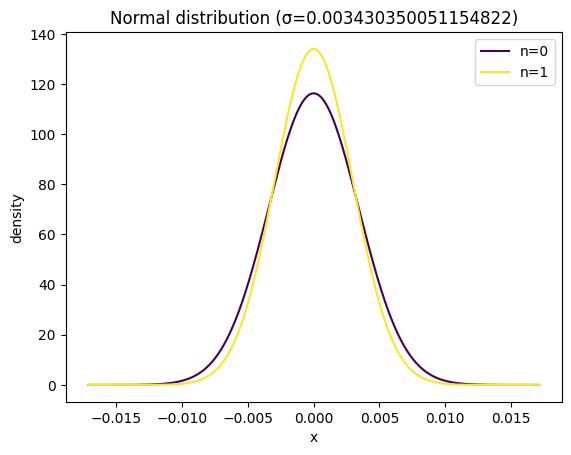

In [ ]:
# with just one value, they are quite synonymous
# it depends on the val being sampled, need to take that out

# this does not deviate enough, 0.5 is not enough
plot_fancy(sigma_w, 0.5*sigma_factor, [0, 1])

sampled values []
sampled values [-0.85234568]


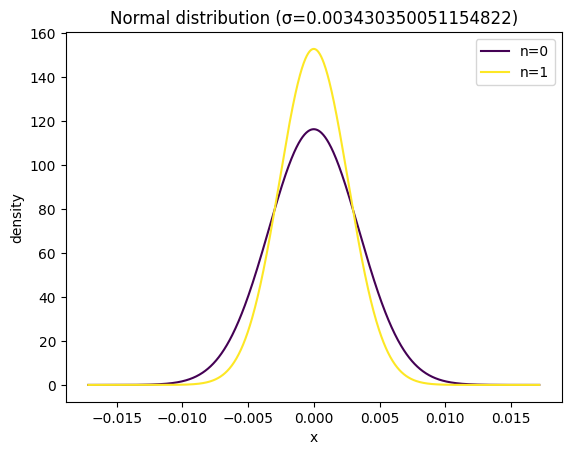

In [ ]:
# even 1 times is not that nice
plot_fancy(sigma_w, 1*sigma_factor, [0, 1])

sampled values []
sigma_ratios 1.0
sampled values [0.16281363]
sigma_ratios 0.03635269431787208


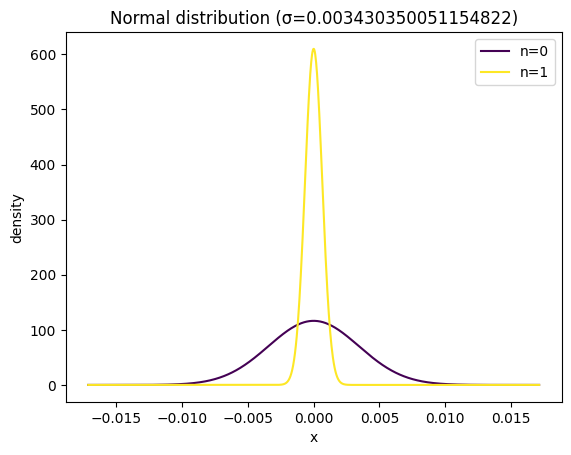

In [ ]:
# this is much taller

# at 16% tis high enough, ratio is 0.03 (3%), not too bad
plot_fancy(sigma_w, 1000*sigma_factor, [0, 1])

sigma0 0.003430350051154822
sampled-values-by-sigma []
sigma_ratios 1.0
sampled-values-by-sigma [0.13684626]
sigma_ratios 0.005311549492861575


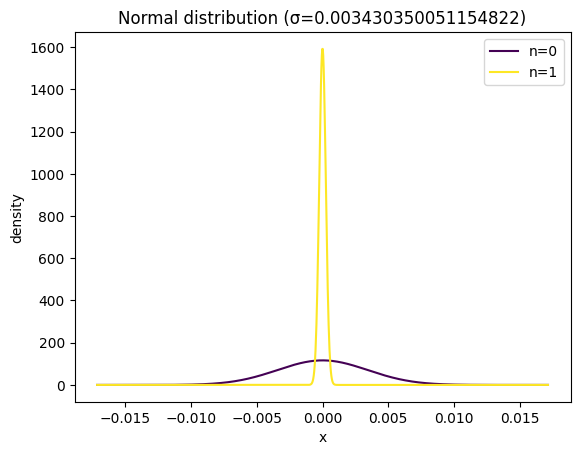

In [ ]:
print("sigma0", sigma_w)
# lets try this now
# 1k -> 10k is interesting range
# 10k is extremely averse to sparseness
plot_fancy(sigma_w, 10000*sigma_factor, [0, 1])

In [ ]:
# at 20% tis high enough, ratio is down to 0.02
plot_fancy(sigma_w, 1000*sigma_factor, [0, 1])

In [ ]:
# 5000 is quite low compared to sigma_w**2
print(5000, 1 /(sigma_w*sigma_w))

5000 84981.25099077147


# NMF try

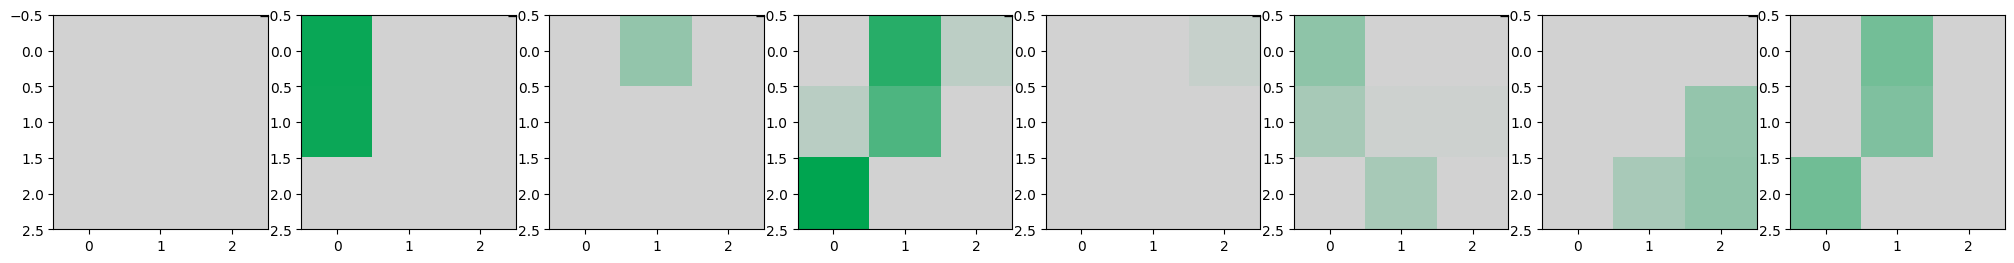

In [ ]:
show_72(lin_patches[0], mode=MODE)

In [15]:
np.all(lin_patches >= 0)

np.True_

In [44]:
from sklearn.decomposition import NMF
# need a lasso on H

nmf = NMF(11, alpha_H=0.5, l1_ratio=0.5, max_iter=2000)
codes = nmf.fit_transform(lin_patches)

/Users/hariomnarang/Desktop/personal/hiccup-ide/backend/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 2000 reached. Increase it to improve convergence.
  warnings.warn(


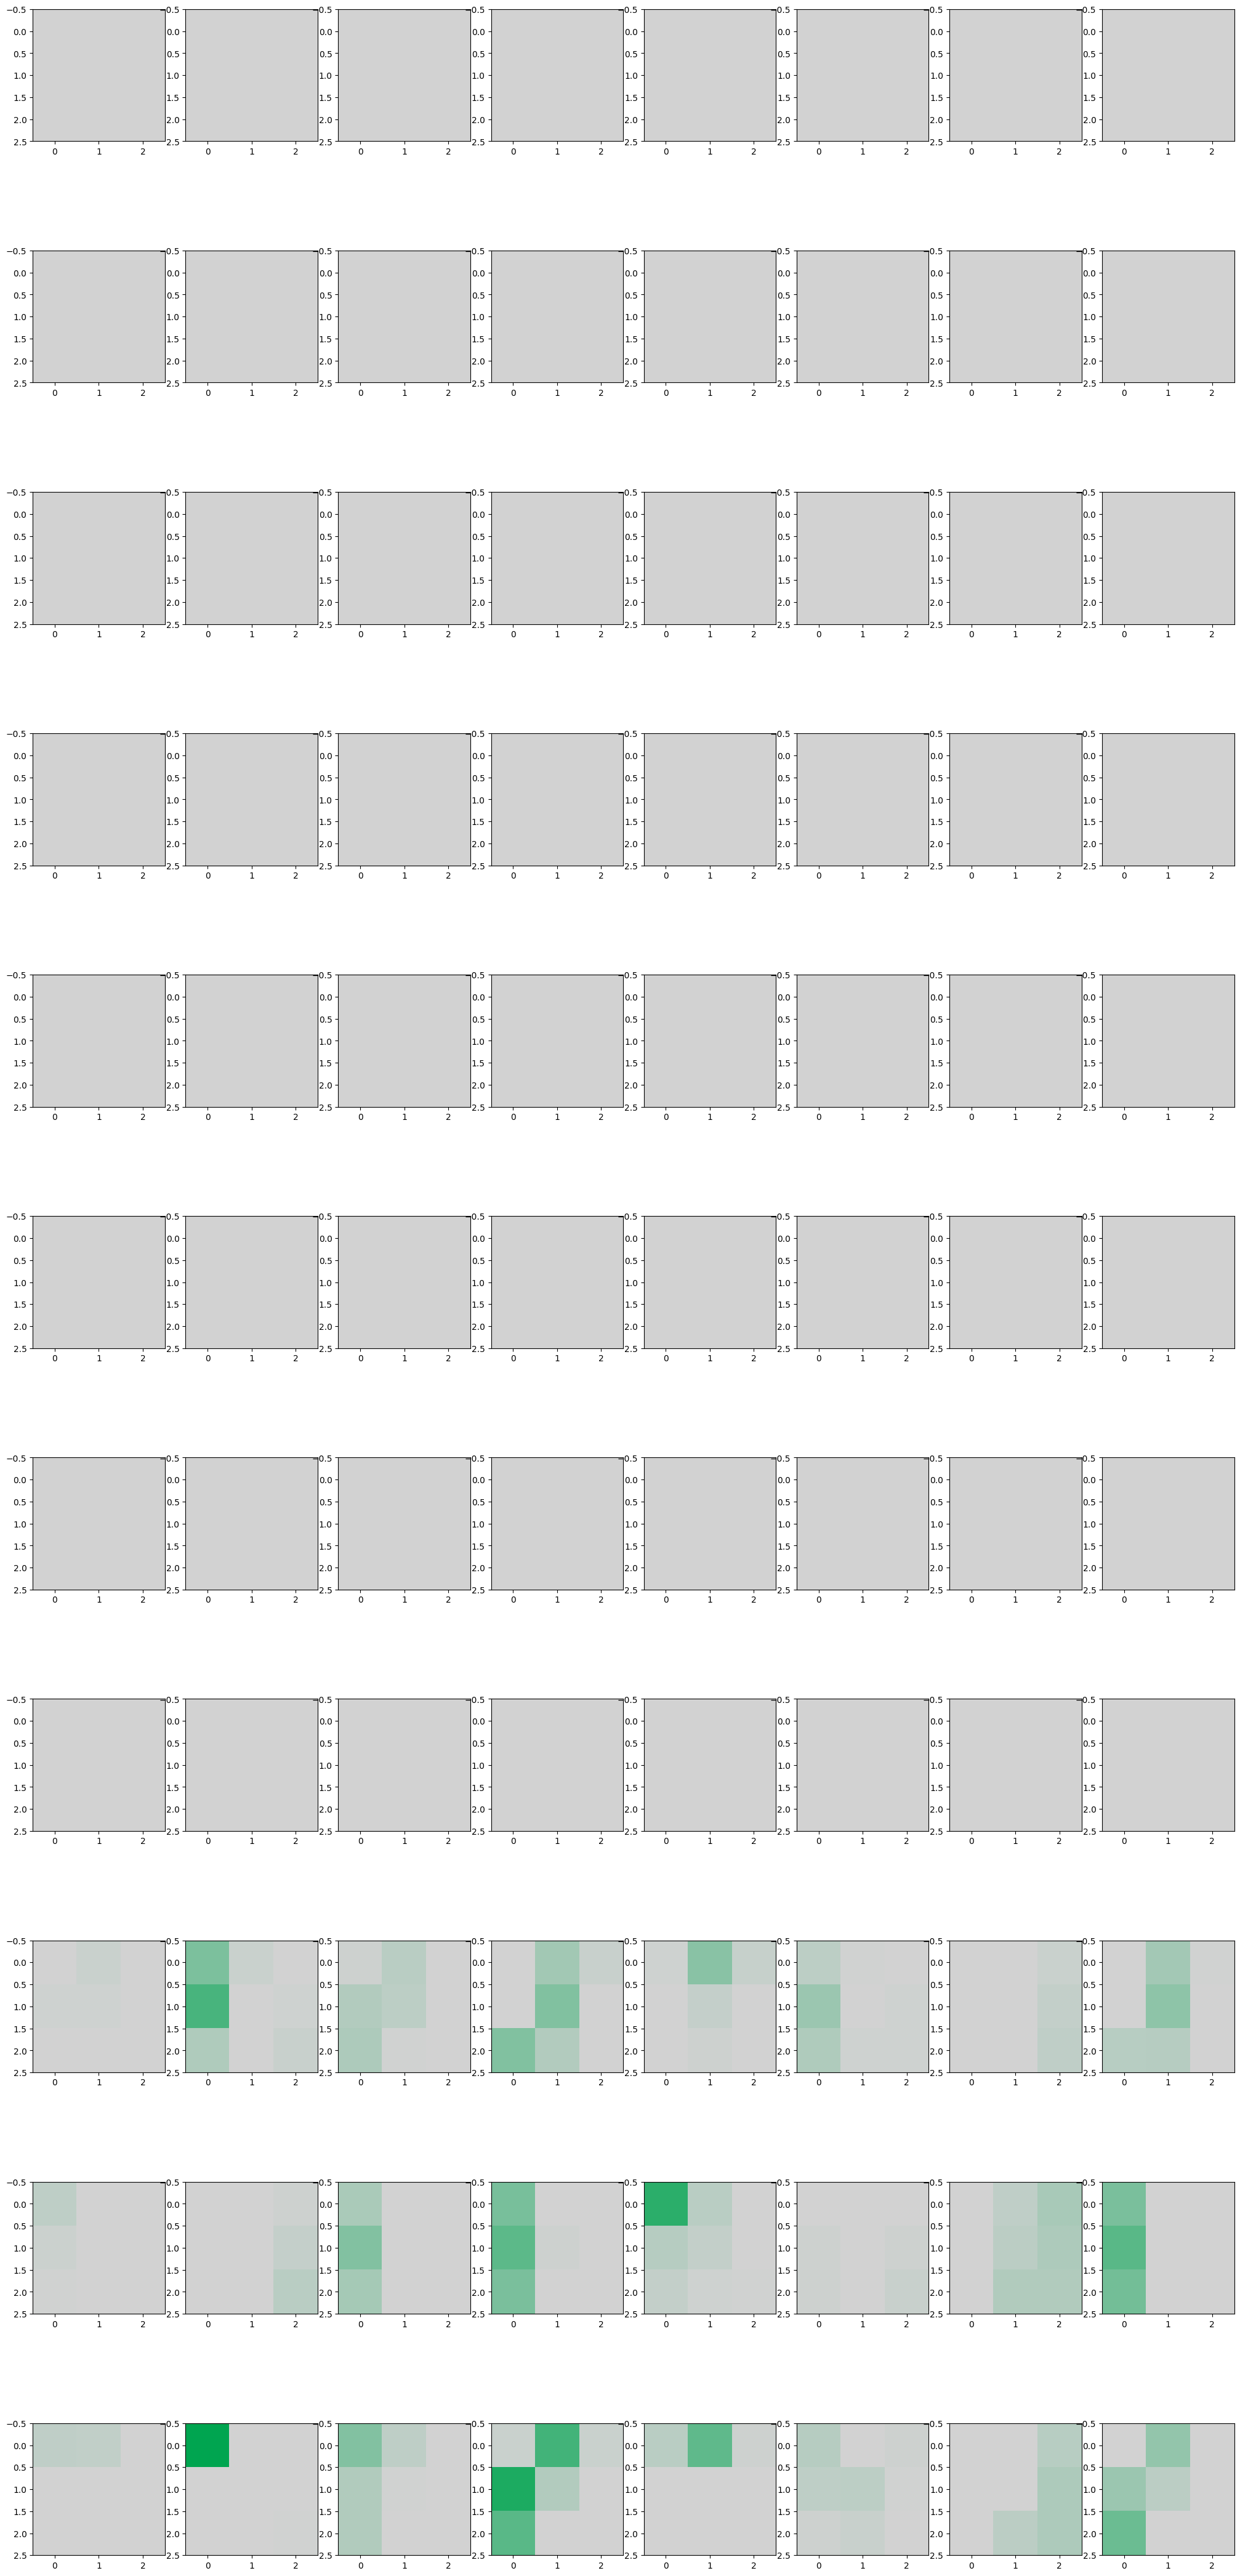

In [45]:
show_72_list(nmf.components_, mode=MODE)

In [24]:
recons = codes @ nmf.components_

codes [0.         0.         0.06903696 0.         0.         0.
 0.         0.25460513 0.24510248 0.         0.00433215]
recons and original, together, same scale


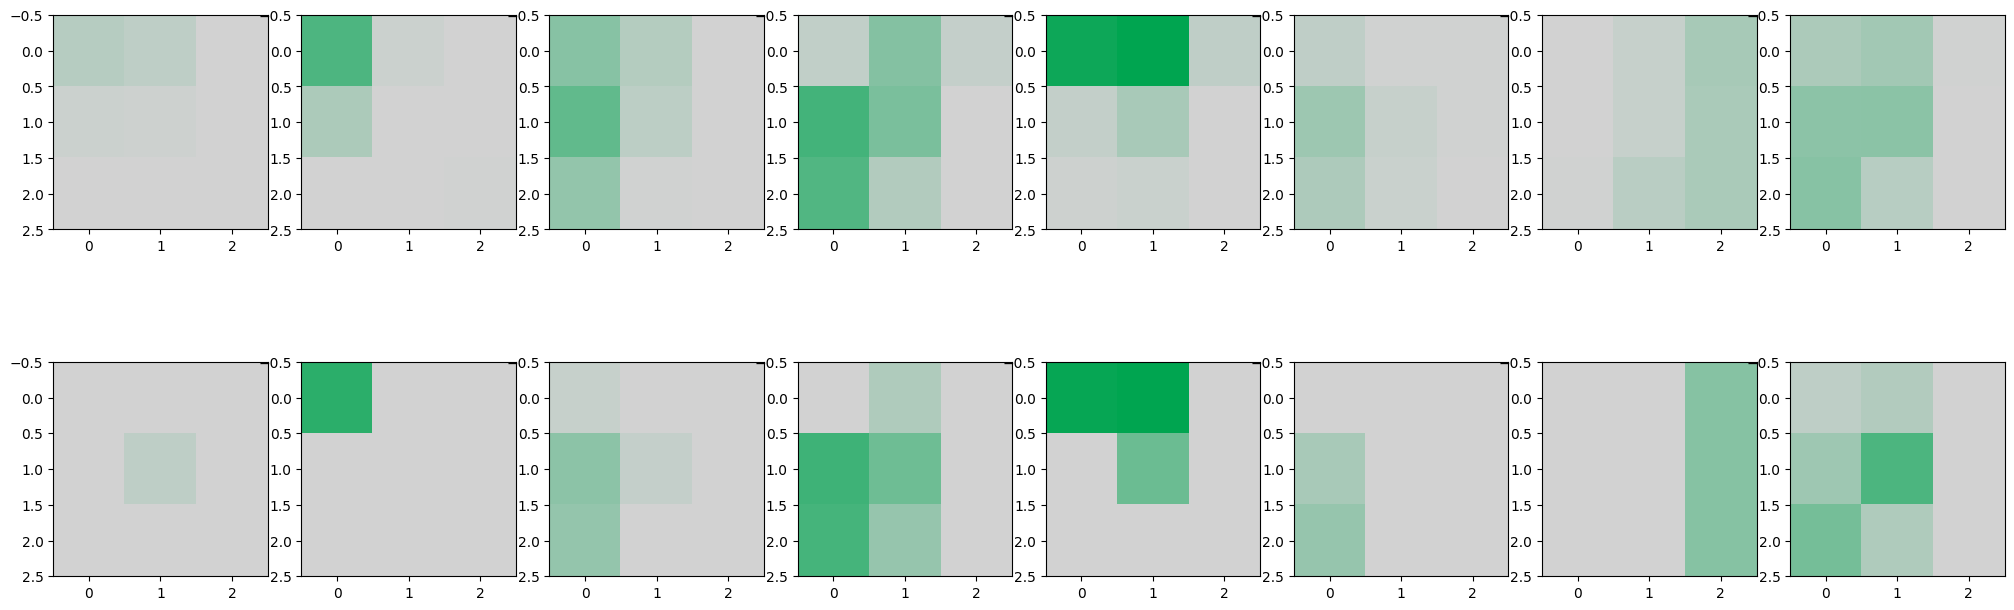

In [32]:
i = 6
print("codes", codes[0])


# tis no good without normalisation, loss lies
print("recons and original, together, same scale")
show_72_list([recons[i], lin_patches[i]], mode=MODE)

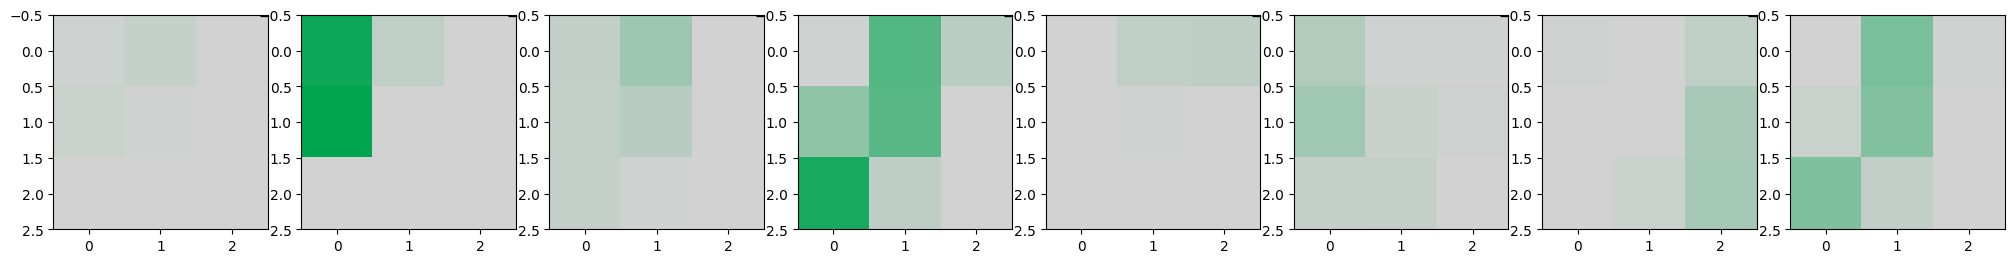

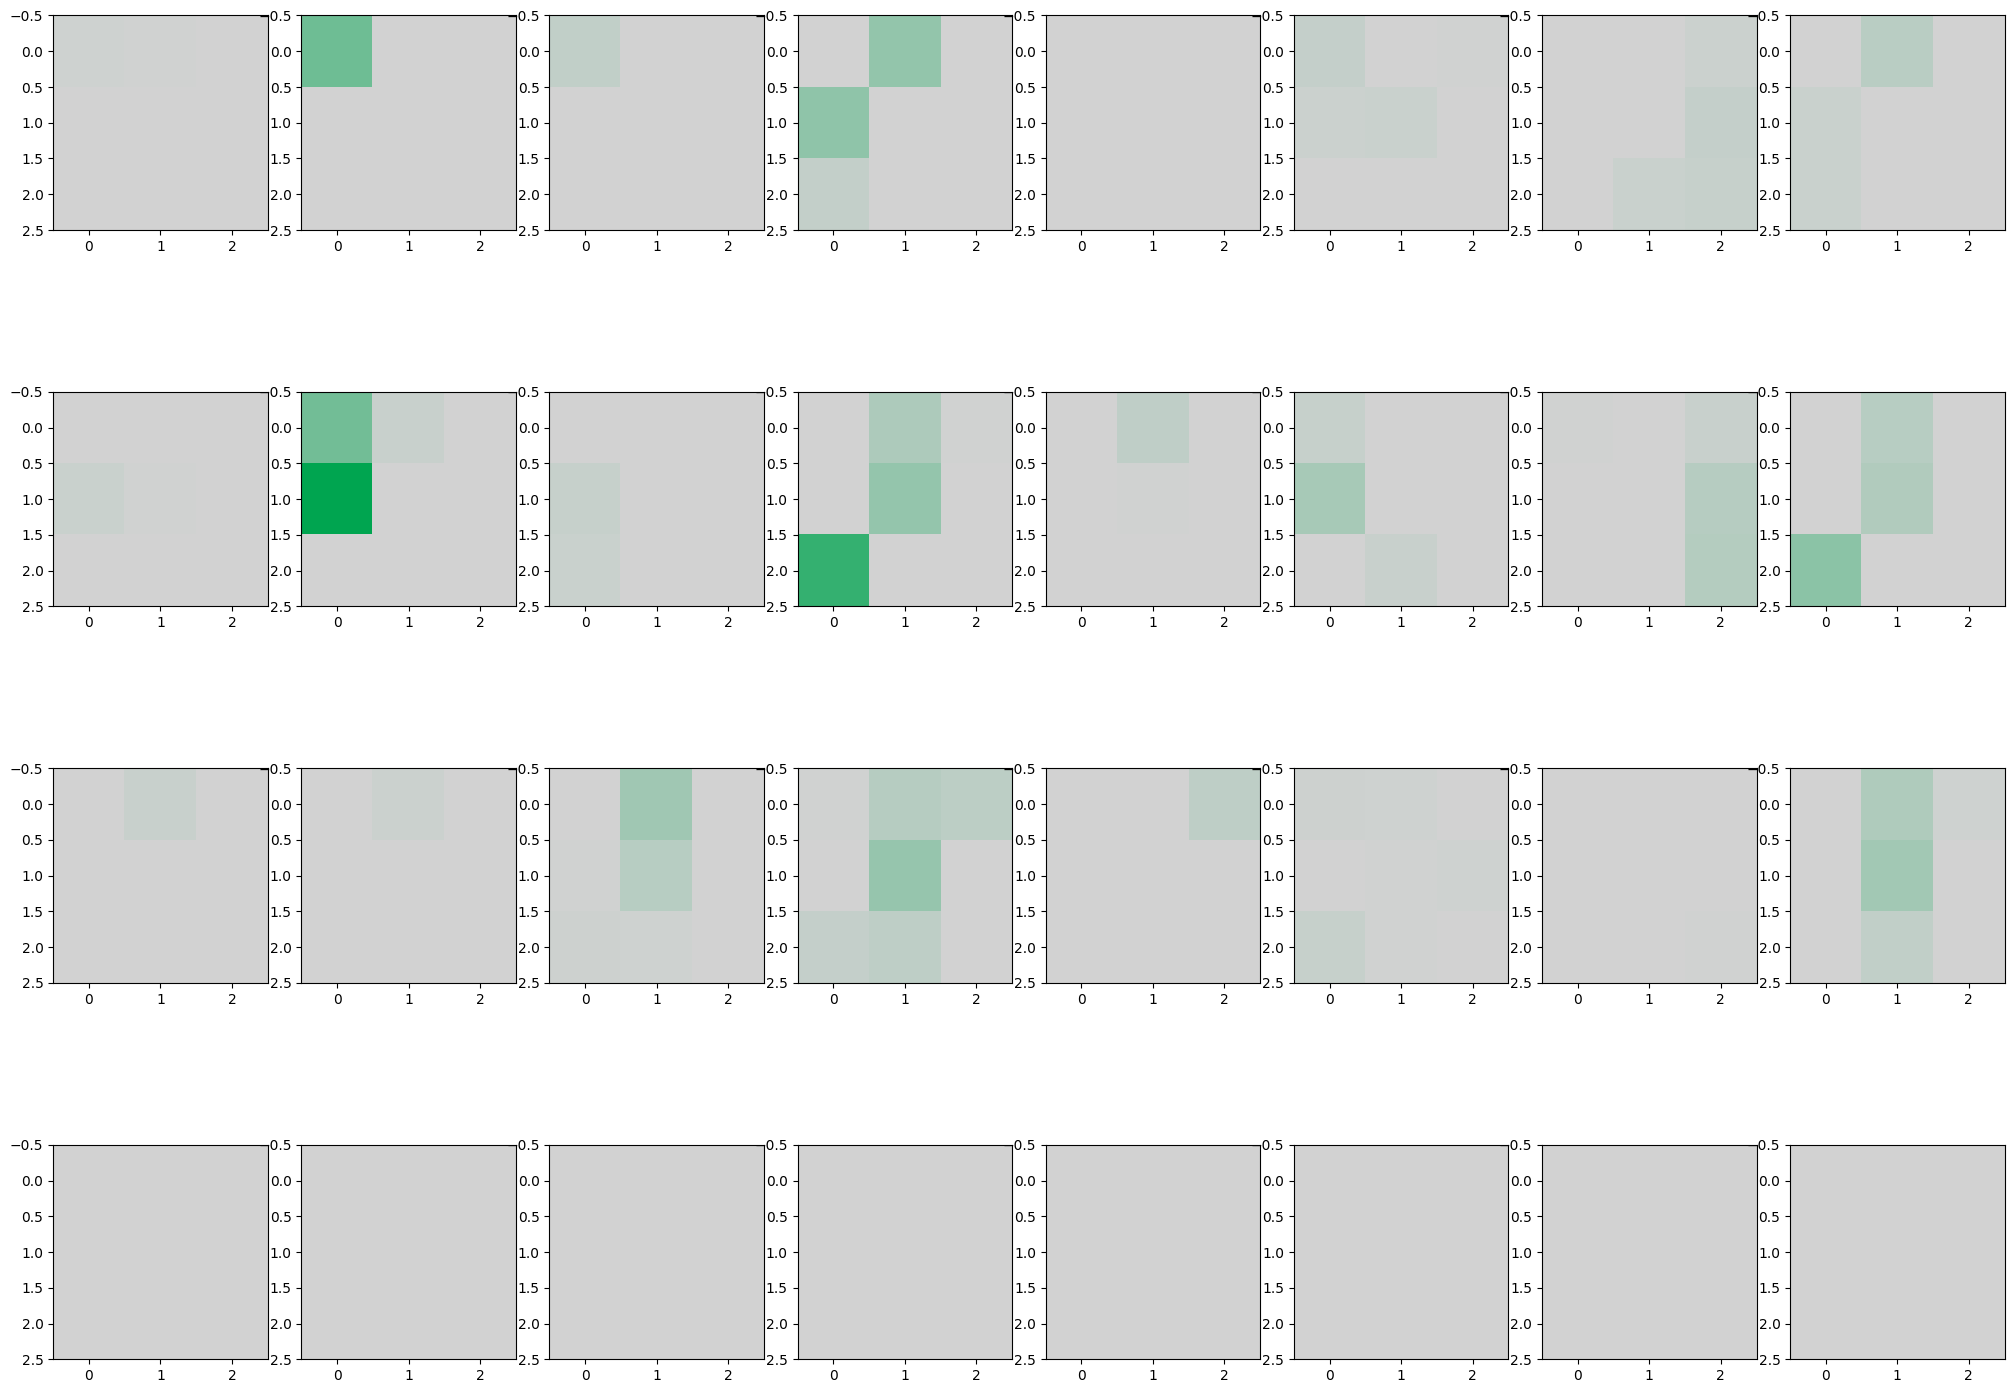

In [34]:
comps = []
for i, c in enumerate(codes[0]):
    if c == 0:
        continue
    comp = c * nmf.components_[i]
    comps.append(comp)

show_72(recons[0], mode=MODE)
show_72_list(comps, mode=MODE)

# standard dict learn

In [ ]:
sparse_pw = lin_pw
(dl, sparse_codes, X), all_dls = do_dict_learn(
    sparse_pw,
    11,
    "minibatch",
    alpha=1.2,
    max_iter=10000,
    transform_max_iter=2000,
    transform_algorithm="lasso_cd",
)
atoms = finetune_dictionary(sparse_pw, dl.components_, sparse_codes)
recons = sparse_codes @ atoms


print("recons, normalized")
show_72(recons[0], mode=MODE)
print("original, normalized")
show_72(sparse_pw[0], mode=MODE)

# tis no good without normalisation, loss lies
print("recons and original, together, same scale")
show_72_list([recons[0], sparse_pw[0]], mode=MODE)

# SAE

## Vanilla

In [ ]:
import torch.nn as nn
import torch.optim as optim


class VanillaSparseAutoencoder(nn.Module):
    def __init__(self, input_dim, n_components):
        super().__init__()
        self.encoder = nn.Linear(input_dim, n_components)
        self.decoder = nn.Linear(n_components, input_dim, bias=False)
        # normalize decoder columns to unit norm (same as sklearn)
        self._normalize_decoder()

    def _normalize_decoder(self):
        with torch.no_grad():
            norms = self.decoder.weight.norm(dim=0, keepdim=True).clamp(min=1.0)
            self.decoder.weight.div_(norms)

    def forward(self, x):
        codes = torch.relu(self.encoder(x))
        recon = self.decoder(codes)
        return recon, codes


def train_sae(
    X,
    n_components,
    alpha=0.1,
    beta=0.1,
    lr=1e-3,
    epochs=2000,
    batch_size=256,
    weights_init_sigma=None,
):
    """
    X: numpy array (n_samples, input_dim)
    n_components: number of dictionary atoms
    alpha: sparsity penalty weight
    """
    X_t = torch.tensor(X, dtype=torch.float32)
    n_samples, input_dim = X_t.shape

    model = VanillaSparseAutoencoder(input_dim, n_components)
    if weights_init_sigma is None:
        torch.nn.init.normal(model.decoder.weights, 0, weights_init_sigma)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        # shuffle
        idx = torch.randperm(n_samples)
        X_t = X_t[idx]

        epoch_loss = 0
        for i in range(0, n_samples, batch_size):
            batch = X_t[i : i + batch_size]
            recon, codes = model(batch)

            recon_loss = ((batch - recon) ** 2).mean()
            sparsity_loss = alpha * codes.abs().mean()
            loss = recon_loss + sparsity_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            model._normalize_decoder()

            epoch_loss += loss.item()

        if epoch % 200 == 0:
            print(
                f"epoch {epoch:4d} | recon_loss {recon_loss:.4f} sparse_loss {sparsity_loss:.4f}"
            )

    # final codes and reconstruction
    with torch.no_grad():
        recon, codes = model(X_t)

    return (
        model,
        codes.numpy(),
        model.decoder.weight.T.detach().numpy(),  # (n_components, input_dim)
        recon.numpy(),
    )

In [ ]:
sparse_pw = lin_pw
model, sparse_codes, components, recons = train_sae(sparse_pw, 10)

In [ ]:
i = 6
# SAE has better performance than dict learning i think
print("recons, normalized")
show_72(recons[i], mode=MODE)
print("original, normalized")
show_72(lin_pw[i], mode=MODE)

# tis no good without normalisation, loss lies
print("recons and original, together, same scale")
show_72_list([recons[i], lin_pw[i]], mode=MODE)

## draw some functions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 1000)
lam = 5

# y = 1 - np.exp(-np.abs(x) / lam)
y = 1 - np.exp(-np.square(x) / lam)

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("1 - exp(-|x| / λ)")
plt.title(f"λ = {lam}")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 1000)


def sigmoid(x, c=0):
    return 1 / (1 + np.exp(-(x - c)))


# symmetric version for your use case
def sigmoid_abs(x, c=0):
    return 1 / (1 + np.exp(-(np.abs(x) - c)))


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# vary c
for c in [0, 1, 2, 3]:
    axes[0].plot(x, sigmoid_abs(x, c), label=f"c={c}")
axes[0].set_title("sigmoid(|x| - c), varying c")
axes[0].legend()
axes[0].grid(True)

# compare with exponential
lam = 1.0
axes[1].plot(x, sigmoid_abs(x, c=1), label="sigmoid(|x| - 1)")
axes[1].plot(
    x, 1 - np.exp(-np.abs(x) / lam), label="1 - exp(-|x| / λ=1)", linestyle="--"
)
axes[1].set_title("sigmoid vs exponential")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 1000)


def soft_abs(x, eps=1.0):
    return np.sqrt(x**2 + eps)
    # return x**2


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# vary eps
for eps in [0.01, 0.1, 0.5, 1.0]:
    axes[0].plot(x, soft_abs(x, eps), label=f"ε={eps}")
axes[0].plot(x, np.abs(x), label="|x|", linestyle="--", color="black")
axes[0].set_title("soft abs: sqrt(x² + ε)")
axes[0].legend()
axes[0].grid(True)


# plug into sigmoid
def sigmoid_softabs(x, c=1, eps=0.1):
    return 1 / (1 + np.exp(-(soft_abs(x, eps) - c)))


for eps in [0.01, 0.1, 0.5, 1.0]:
    axes[1].plot(x, sigmoid_softabs(x, c=0.1, eps=eps), label=f"ε={eps}")
axes[1].set_title("sigmoid(softabs(x) - c)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 1000)


def soft_abs(x, eps=0.01):
    return np.sqrt(x**2 + eps)


def tanh_softabs(x, lam=1.0, eps=0.01):
    return np.tanh(soft_abs(x, eps) / lam)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# vary lam
for lam in [0.5, 1.0, 2.0, 3.0, 10.0]:
    axes[0].plot(x, tanh_softabs(x, lam=lam), label=f"λ={lam}")
axes[0].set_title("tanh(softabs(x) / λ), varying λ")
axes[0].legend()
axes[0].grid(True)

# compare all candidates
axes[1].plot(x, tanh_softabs(x, lam=1.0), label="tanh(softabs(x))")
axes[1].plot(
    x, 1 - np.exp(-np.abs(x) / 1.0), label="1 - exp(-|x| / λ=1)", linestyle="--"
)
axes[1].set_title("tanh vs exponential")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## L2 on weight without normalization

Interesting, if the number of components is less, the model is driving down the sparse loss and l2 loss.  
What can be the reason for this?  

If there are not enough components, it might not be able to correctly make a good representation, 0 might be the best representation.  
Nice nice. Its an indicator anyways.  

In [ ]:
import torch.nn as nn
import torch.optim as optim


class SaeWeightsL2(nn.Module):
    def __init__(self, input_dim, n_components):
        super().__init__()
        self.encoder = nn.Linear(input_dim, n_components)
        self.decoder = nn.Linear(n_components, input_dim, bias=False)

    def forward(self, x):
        codes = torch.relu(self.encoder(x))
        recon = self.decoder(codes)
        return recon, codes


def train_sae_weights_l2(
    X,
    n_components,
    alpha=0.1,
    beta=0.1,
    lr=1e-3,
    epochs=2000,
    batch_size=256,
    weights_init_sigma=None,
):
    """
    X: numpy array (n_samples, input_dim)
    n_components: number of dictionary atoms
    alpha: sparsity penalty weight
    """
    X_t = torch.tensor(X, dtype=torch.float32)
    n_samples, input_dim = X_t.shape

    model = SaeWeightsL2(input_dim, n_components)
    if weights_init_sigma is not None:
        nn.init.normal_(model.decoder.weight, mean=0, std=weights_init_sigma)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        # shuffle
        idx = torch.randperm(n_samples)
        X_t = X_t[idx]

        epoch_loss = 0
        for i in range(0, n_samples, batch_size):
            batch = X_t[i : i + batch_size]
            recon, codes = model(batch)

            recon_loss = ((batch - recon) ** 2).mean()
            sparsity_loss = alpha * codes.abs().mean()
            l2_loss = beta * (model.decoder.weight**2).mean()
            loss = recon_loss + sparsity_loss + l2_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        if epoch % 200 == 0:
            print(
                f"epoch {epoch:4d} | recon_loss {recon_loss:.4f} sparse_loss {sparsity_loss:.4f}, l2_loss {l2_loss:.4f}"
            )

    # final codes and reconstruction
    with torch.no_grad():
        recon, codes = model(X_t)

    return (
        model,
        codes.numpy(),
        model.decoder.weight.T.detach().numpy(),  # (n_components, input_dim)
        recon.numpy(),
    )

In [ ]:
# L2 on weights does weird shit
model, codes, decoder, recons = train_sae_weights_l2(lin_pw, 12)

In [ ]:
i = 6
# SAE has better performance than dict learning i think
print("recons, normalized")
show_72(recons[i], mode=MODE)
print("original, normalized")
show_72(lin_pw[i], mode=MODE)

# tis no good without normalisation, loss lies
print("recons and original, together, same scale")
show_72_list([recons[i], lin_pw[i]], mode=MODE)

## Normalized weights and inputs

I dont see much evidence of getting better with this also

In [ ]:
SIGMA = 0.5

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
lin_pw_scaled = scaler.fit_transform(lin_pw) * SIGMA

In [ ]:
show_72_list([lin_pw[0], lin_pw_scaled[0]], mode=MODE)

In [ ]:
model, codes, decoder, recons = train_sae(
    lin_pw_scaled, 20, weights_init_sigma=SIGMA, alpha=0.5
)

In [ ]:
codes[10]

In [ ]:
i = 4
# SAE has better performance than dict learning i think
scaled_back_recons = scaler.inverse_transform(recons / SIGMA)
r = scaled_back_recons[i]
print("recons, normalized")
show_72(r, mode=MODE)
print("original, normalized")
show_72(lin_pw[i], mode=MODE)

# tis no good without normalisation, loss lies
print("recons and original, together, same scale")
show_72_list([r, lin_pw[i]], mode=MODE)

## Sparse mask SAE

Lets see if this gives anything useful

In [ ]:
import torch.nn as nn
import torch.optim as optim


class SparseAutoencoderWithSparseMask(nn.Module):
    def __init__(self, input_dim, n_components, clipper_denominator):
        super().__init__()
        self.e1 = nn.Linear(input_dim, n_components)
        self.e2 = nn.Linear(input_dim, n_components)
        # self.clipper_denominator = clipper_denominator

        self.decoder = nn.Linear(n_components, input_dim, bias=False)

    def forward(self, x):
        # y = 1 - np.exp(-np.square(x) / lam)
        codes = torch.relu(self.e1(x))
        sparse_coeffs = torch.relu(self.e2(x))

        # clipped_sparse_coeffs = 1 - torch.exp(-torch.square(sparse_coeffs) / self.clipper_denominator)
        # clipped_sparse_coeffs = torch.exp(-torch.square(sparse_coeffs) / self.clipper_denominator)

        multipliers = sparse_coeffs * codes
        recon = self.decoder(multipliers)

        return recon, codes, sparse_coeffs, multipliers


def train_sparse_mask_sae(
    X,
    n_components,
    alpha=0.1,
    beta=0.1,
    gamma=0.1,
    clipper_denominator=1,
    lr=1e-3,
    epochs=2000,
    batch_size=256,
):
    """
    X: numpy array (n_samples, input_dim)
    n_components: number of dictionary atoms
    alpha: sparsity penalty weight
    """
    X_t = torch.tensor(X, dtype=torch.float32)
    n_samples, input_dim = X_t.shape

    model = SparseAutoencoderWithSparseMask(
        input_dim, n_components, clipper_denominator
    )
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        # shuffle
        idx = torch.randperm(n_samples)
        X_t = X_t[idx]

        epoch_loss = 0
        for i in range(0, n_samples, batch_size):
            batch = X_t[i : i + batch_size]
            recon, codes, sparse_coeffs, _ = model(batch)

            recon_loss = ((batch - recon) ** 2).mean()
            sparsity_loss = alpha * sparse_coeffs.abs().mean()
            loss = recon_loss + sparsity_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        if epoch % 200 == 0:
            print(
                f"epoch {epoch:4d} | recon_loss {recon_loss:.4f} sparse_loss {sparsity_loss:.4f}"
            )
            # print(f"epoch {epoch:4d} | recon_loss {recon_loss:.4f} weights_l2 {l2_loss:.4f} sparse_loss {sparsity_loss:.4f} codes_loss {codes_loss:.4f}")

    # final codes and reconstruction
    with torch.no_grad():
        recon, codes, _, multipliers = model(X_t)

    return (
        model,
        multipliers.numpy(),
        model.decoder.weight.T.detach().numpy(),  # (n_components, input_dim)
        recon.numpy(),
    )

In [ ]:
# sparse_pw = make_sparse(lin_pw)
sparse_pw = lin_pw
# current_mean_norm = np.linalg.norm(sparse_pw, axis=-1).mean()
# normalized_sparse_pw = sparse_pw / current_mean_norm  # mean norm = 1

model, sparse_codes, components, recons = train_sparse_mask_sae(sparse_pw, 10)

In [ ]:
i = 10
# SAE has better performance than dict learning i think
print("recons, normalized")
show_72(recons[i], mode=MODE)
print("original, normalized")
show_72(lin_pw[i], mode=MODE)

# tis no good without normalisation, loss lies
print("recons and original, together, same scale")
show_72_list([recons[i], lin_pw[i]], mode=MODE)

# Dictionary learning compare

Technically this is also not bad, if the scale was okay.   
Generally, all of them have a problem with scale. It's the L1 killing scale.  

There is something about dictionary learning's algorithm, it does weights first, then scalar codes, then weights, then scalar codes. and ends up being quite stable (across different seeds). Compared to SAE which gives quite different reconstructions every time.  

Why?


I'm actually back at dictionary learning for some reason. There are two options now.
- Fix the shrinkage somehow in vanilla dictionary learning
- Fix seed stability in SAE (much harder?)

Coordinate descent does one atom at a time, which sounds promising.   
This is getting harder than i thought it would be, the obvious things are already done lol.  


Lets assume that the dictionary atoms are good now. we can freeze them. or maybe, we can freeze the sparse codes and update the dict atoms?  Lets try that.  
How would i want to do that? the simplest is basic gradient descent i guess.  

In [ ]:
(dl, sparse_codes, X), all_dls = do_dict_learn(
    lin_pw,
    6,
    "minibatch",
    alpha=0.8,
    max_iter=10000,
    transform_max_iter=2000,
    transform_algorithm="lasso_cd",
)
recons = sparse_codes @ dl.components_

In [ ]:
recons = sparse_codes @ dl.components_

In [ ]:
i = 4
print(sparse_codes[i])
# print("recons, normalized")
# show_72(recons[i], mode=MODE)
# print("original, normalized")
# show_72(lin_pw[i], mode=MODE)

# tis no good without normalisation, loss lies
print("recons and original, together, same scale")
show_72_list([recons[i], lin_pw[i]], mode=MODE)

In [ ]:
for j, s in enumerate(sparse_codes[i]):
    if s != 0:
        show_72(atoms[j], mode=MODE)

In [ ]:
# the number of stuff we need to learn is significantly higher now
# lmaos
def sweep_over_n_components(inputs):
    l2_dicts = {}
    sparsity_per_row = {}
    distance_between_seeds = {}
    comps_gt_1_per_row_ratio = [0]  # placeholder for 0
    for comp in tqdm(range(1, 60, 5)):
        (dl, sparse_codes, X), all_dls = do_dict_learn(
            inputs,
            comp,
            "minibatch",
            alpha=1.2,
            max_iter=20000,
            transform_algorithm="lasso_cd",
        )
        error_metrics = get_metrics(dl, sparse_codes, X)
        sparsity_per_row[comp] = get_sparsity_in_rows(sparse_codes)
        l2_dicts[comp] = error_metrics["l2"]
        comps_gt_1_per_row_ratio.append(
            get_sparse_codes_ratio_with_more_than_1_active_node(sparse_codes)
        )

    print("n_components v/s loss")
    plot_error_metrics(l2_dicts)

    print("n_components v/s sparsity")
    plot_error_metrics(sparsity_per_row)

    plt.plot(comps_gt_1_per_row_ratio)
    plt.show()

In [ ]:
sweep_over_n_components(sparse_pw)

In [ ]:
def get_sparse_components(sparse_codes, dl_components, index):
    codes = sparse_codes[index]
    return [codes[i] * dl_components[i] for i in range(len(codes)) if codes[i] != 0]

In [ ]:
import gc

gc.collect()

In [ ]:
show_72(sparse_pw[0])

In [ ]:
import numpy as np
from numpy.linalg import lstsq


def relaxed_lasso_codes(X, dictionary, lasso_codes):
    """
    Given lasso codes (sparse, shrunk), re-fit least squares on the
    active atoms only. Returns unbiased sparse codes.

    Parameters
    ----------
    X : array (n_samples, n_features)
    dictionary : array (n_components, n_features)  — dl.components_
    lasso_codes : array (n_samples, n_components)  — from dl.transform(X)

    Returns
    -------
    relaxed_codes : array (n_samples, n_components)
    """
    relaxed_codes = np.zeros_like(lasso_codes)

    for i, (x, code) in enumerate(zip(X, lasso_codes)):
        active = np.where(code != 0)[0]
        if len(active) == 0:
            continue
        active_atoms = dictionary[active]  # (n_active, n_features)
        coeffs, _, _, _ = lstsq(active_atoms.T, x, rcond=None)
        relaxed_codes[i, active] = coeffs

    return relaxed_codes

In [ ]:
(dl, sparse_codes, X), all_dls = do_dict_learn(
    sparse_pw,
    11,
    "minibatch",
    alpha=1.2,
    max_iter=10000,
    transform_max_iter=2000,
    transform_algorithm="lasso_cd",
)
recons = sparse_codes @ dl.components_

print(
    "ratio of sparse codes which have > 1 components",
    get_sparse_codes_ratio_with_more_than_1_active_node(sparse_codes),
)
print(
    "sparsity inside rows (number of non-zero / number of eles in a row)\n",
    get_sparsity_in_rows(sparse_codes),
)
print("loss histogram across exmaples")
plt.hist(get_loss(dl, sparse_codes, X))
plt.show()


print("count of the number of times an atom is used")
activation_freq = (sparse_codes != 0).sum(axis=0)
plt.figure(figsize=(12, 4))
plt.bar(range(len(activation_freq)), np.sort(activation_freq)[::-1])
plt.xlabel("Atom rank")
plt.ylabel("Activation count")
plt.title("Atom activation frequency")
plt.show()

In [ ]:
relaxed_codes = relaxed_lasso_codes(X, dl.components_, sparse_codes)

In [ ]:
relaxed_recons = relaxed_codes @ dl.components_

In [ ]:
def show_normalized(x, recons):
    norm = Normalizer("max")
    show_72_list(
        [
            norm.fit_transform(recons.reshape(1, -1)),
            norm.fit_transform(x.reshape(1, -1)),
        ],
        mode=MODE,
    )
    plt.show()

In [ ]:
show_72_list([X[3], relaxed_recons[3]])

In [ ]:
losses = get_loss(dl, sparse_codes, X)
sorted_loss_idxs = np.argsort(losses)

In [ ]:
# very weird that these got into the main code
X[i], sparse_pw[i]

In [ ]:
# huh, it seems there are empty values in this
# lol
# interestingly, this is the highest loss
# which is not very bad
# a recurring problem is that the final things are much smaller in magnitude
# compared to what we want
# should i change my normalizing?
i = sorted_loss_idxs[-1]
show_72_list([X[i], recons[i]])

In [ ]:
# these are definitely not pure components, have a lot of redundancy
# im also not able to get perfect sparsity
# print(sparse_codes)
# show_72_list([norm.fit_transform(recons[0].reshape(1,-1)), norm.fit_transform(X[0].reshape(1,-1))], mode=MODE)
print("recons vs orig normalized")
# show_normalized(recons[0], X[0])
show_72(recons[3])
show_72(X[3])

print("sparse components")
# there was only one component lol
show_72_list(get_sparse_components(sparse_codes, dl.components_, 0), mode=MODE)

In [ ]:
def patch_from_recons(recons, kernel):
    # simply pointwise divide by kernel
    k = kernel.reshape(-1)
    recons = recons.reshape(-1)
    # patch = recons / k
    patch = np.where(k == 0, np.nan, recons / k)
    return patch.reshape(8, 3, 3)

In [ ]:
patches[0].shape

In [ ]:
S(tsl(patches[0]), (20, 8), 8, mode=MODE)
S(tsl(patch_from_recons(recons[0], kernel)), (20, 8), 8, mode=MODE)
S(tsl(kernel), (20, 8), 8, mode=MODE)
plt.show()

The main job is somehow being able to interpret these results.  
Since the reconstructed array has very less noise, we want to create a metric on how similar each is to the other.  
we can do this using cosine distances, or euclidean, lets see

In [ ]:
distances = cosine_distances(recons)
idx = np.argmin(distances[0][1:]).item()
idx, distances[0][idx]

The reconstruction is not very bad though, its now useful to see the similarities between the two by comparing the input images

In [ ]:
input_acts_a = get_full_activations_of_layer(
    "layers.1", Input.objects.get(alias=sm_ids[0]["input"])
)
input_acts_b = get_full_activations_of_layer(
    "layers.1", Input.objects.get(alias=sm_ids[idx]["input"])
)

In [ ]:
def get_rect(y, x, ksize=3, stride=2, padding=1):
    (y0, x0), (y1, x1) = get_receptive(y, x, ksize, stride, padding)
    return (y0, x0, y1 - y0, x1 - x0)

In [ ]:
axes = S(tsl(input_acts_a), (15, 5), ncols=8, mode=MODE)
for ax in axes:
    mk_rect_on_ax(ax, *get_rect(R, C))
plt.show()
axes = S(tsl(input_acts_b), (15, 5), ncols=8, mode=MODE)
for ax in axes:
    mk_rect_on_ax(ax, *get_rect(R, C))
plt.show()

In [ ]:
S(tsl(patch_from_recons(recons[0], kernel)), (20, 8), 8, mode=MODE)
plt.show()

In [ ]:
def patch_from_recons(recons, kernel):
    # simply pointwise divide by kernel
    k = kernel.reshape(-1)
    recons = recons.reshape(-1)
    # patch = recons / k
    patch = np.where(k == 0, np.nan, recons / k)
    return patch.reshape(8, 3, 3)

Reconstruction is bad for smaller components for sure, not sure if that is a good thing or bad for now.  

# Check what pattern a component is finding

- The first and the most interesting is seeing if patterns are coherent.
  - That is, i can find what meaning came out
  - The easiest is to first find an input where a single component fired alone.  
    - In this case, i would like to see the pattern the component caught
    - basically make rects around all the vector components where the component was non-zero
- We do this across input activations

In [ ]:
def find_pure_patches(codes, k, threshold=1e-3):
    other_cols = np.concatenate([codes[:, :k], codes[:, k + 1 :]], axis=1)
    mask = (np.abs(codes[:, k]) > threshold) & (
        np.all(np.abs(other_cols) < threshold, axis=1)
    )
    return np.where(mask)[0]


def find_high_contribution_patches(codes, k, percentile=75):
    contributions = np.abs(codes[:, k])
    threshold = np.percentile(contributions[contributions > 0], percentile)
    return np.where(contributions >= threshold)[0]


def find_patches_for_component(codes, k, pure_threshold=1e-3, high_percentile=75):
    pure = find_pure_patches(codes, k, threshold=pure_threshold)
    high = find_high_contribution_patches(codes, k, percentile=high_percentile)

    high_only = high[~np.isin(high, pure)]
    high_only_sorted = high_only[np.argsort(np.abs(codes[high_only, k]))[::-1]]

    return np.concatenate([pure, high_only_sorted])

In [ ]:
def draw_patches_with_rects_on_coords(input_acts, recons_3d, non_zero_idxs):
    print("input activations")
    axes = S(tsl(input_acts), (20, 8), 8, mode=MODE)
    for ax_idx, ax in enumerate(axes):
        for non_zero_i in non_zero_idxs:
            if non_zero_i[0] == ax_idx:
                _, y_rel, x_rel = non_zero_i
                (y0, x0), _ = get_receptive(R, C)
                pw_val = recons_3d[*non_zero_i]
                color = "r" if pw_val < 0 else "black"
                mk_rect_on_ax(ax, y0 + y_rel, x0 + x_rel, 1, 1, color)
    plt.show()


def summarize_pattern_of_component(comp_num, sm_ids, sparse_codes, dl, kernel):
    if sparse_codes[:, comp_num].sum() == 0:
        print("dead component, skipping")
        return
    idxes = find_patches_for_component(sparse_codes, comp_num)
    if len(idxes) == 0:
        print(f"could not find any contribution of component {comp_num}, its redundant")
        return

    i = idxes[0]
    for j, i in enumerate(idxes[:5]):
        recons_i = sparse_codes[i] @ dl.components_
        recons_3d = recons_i.reshape(8, 3, 3)
        non_zero_idxs = np.argwhere(np.abs(recons_3d) > 0.005)

        input_acts = get_full_activations_of_layer(
            "layers.1", Input.objects.get(alias=sm_ids[i]["input"])
        )
        patch_i = patch_from_recons(recons_i, kernel)

        if j == 0:
            print("first patch")
            print("reconstructed pointwise")
            show_72(recons_i, mode=MODE)
            plt.show()
            print("reconstructed patch")
            S(tsl(patch_i), (20, 8), 8, mode=MODE)
            plt.show()
            print("kernel")
            S(tsl(kernel), (20, 8), 8, mode=MODE)
            plt.show()

        print("##### input activations ######")
        draw_patches_with_rects_on_coords(input_acts, recons_3d, non_zero_idxs)

    # print("activations for multiple inputs")
    # for j, i in enumerate(idxes[:5]):
    #     recons_i = (sparse_codes[i] @ dl.components_)
    #     # recons_3d = recons_i.reshape(8,3,3)
    #     # nonzero_spatial = np.any(recons_3d != 0, axis=0)  # (3, 3) bool mask
    #     # nonzero_rc = np.argwhere(nonzero_spatial)  # list of (r, c) in patch space
    #     non_zero_idxs = np.argwhere(np.abs(recons_i.reshape(8,3,3)) > 0.005)

In [ ]:
summarize_pattern_of_component(3, sm_ids, sparse_codes, dl, kernel)

In [ ]:
summarize_pattern_of_component(3, sm_ids, sparse_codes, dl, kernel)

In [ ]:
# def get_rect(y, x, ksize=3, stride=2, padding=1):
#     (y0,x0), (y1,x1) = get_receptive(y, x, ksize, stride, padding)
#     return (y0, x0, y1-y0, x1-x0)
axes = S(tsl(input_acts_0), (15, 5), ncols=8, mode=MODE)
for ax in axes:
    mk_rect_on_ax(ax, *get_rect(R, C))
plt.show()
axes = S(tsl(input_acts_21), (15, 5), ncols=8, mode=MODE)
for ax in axes:
    mk_rect_on_ax(ax, *get_rect(R, C))
plt.show()

In [ ]:
find_pure_patches(sparse_codes, 7, 1e-5)

In [ ]:
sparse_codes[130]

In [ ]:
sparse_codes.shape

In [ ]:
# i.